<br/>
<div class="alert alert-info">
Привет, Кирилл!
</div>

<div style="border:solid Chocolate 2px; padding: 40px">
 
<b> Андрей, привет!👋</b> 

Меня зовут Кирилл Васильев, я буду ревьюером твоего проекта. Я предлагаю общаться на «ты», но если привычнее на «вы», просто скажи об этом! 

Я буду оставлять комментарии в твоем проекте. Пожалуйста, не удаляй их, они могут быть полезны в случае повторной проверки.

Свои комментарии я буду обозначать <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:
  
<br/> 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным. Здесь же я могу давать советы и предложения.
</div>
 
<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div> 
  

<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

  
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>  

 
<br/>
<div class="alert alert-info">
Рекомендую для твоих комментариев использовать синий или любой другой цветной фон. Я постараюсь ничего не пропустить, но если комментарии будут выделены, то это мне очень поможет!
</div>
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самостоятельно найти и исправить ее. На реальной работе твой руководитель будет поступать также. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку.



# https://github.com/2Myaka2/DataScience_projects

## работал в репозитории

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

С одной стороны это только похвально, но почему там описания сплошными текстами без абзацев итд, это же нечитаемо? И что там делают другие проекты в одном и том же репозитории? 

<br/>
<div class="alert alert-info">
Подчистил репозиторий (совсем забыл про него)
</div>

# Прогнозирование риска задержки доставки CargaPronto: кластеризация клиентов как источник признаков

**Заказчик:** CargaPronto, логистический оператор (США и Пуэрто-Рико)

**Задача:** бинарная классификация — предсказать риск нарушения срока доставки
(`late_delivery_risk`) на момент оформления заказа.

**Целевая метрика:** ROC-AUC ≥ 0.75 на тестовой выборке.

**Данные:** `ds_s18_customers.csv` — 20 652 профиля клиентов с координатами и
RFM-показателями; `ds_s18_orders.csv` — 180 519 товарных позиций за период
2015-01-01 — 2018-01-31.

**Гипотеза заказчика:** риск задержки определяется профилем клиента — его
географическим положением и потребительским поведением.

**Подход:** K-Means++ по координатам и RFM-профилям формирует признаки логистической
зоны и поведенческого сегмента; вклад этих признаков измеряется сравнением базовых и
финальных моделей (логистическая регрессия и CatBoost) при неизменных гиперпараметрах.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично по описанию. Цели и задачи ясны, обозначены корректно. Отлично, что перерабатываешь текст задания в удобном для потенциального читателя формате.
    
    
Итак, решаем задачу бинарной классификации + создаем новые фичи с помощью knn.
  

   

##  Импорт библиотек, выполнение базовых настроек

Загрузите все необходимые для выполнения проекта библиотеки и другие компоненты.



In [1]:
%%writefile requirements.txt
numpy==1.26.4
pandas==2.2.3
scipy==1.13.1

scikit-learn==1.6.1

catboost==1.2.7

matplotlib==3.9.4
seaborn==0.13.2
phik==0.12.4

joblib==1.5.3
ipykernel==6.29.5

Overwriting requirements.txt


In [2]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 В нашем случае можно без лишней «бюрократии», просто реализовать pip install нужных зависимостей.
   

In [3]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

import phik
import itertools

# Разбиение данных по группам клиентов 
from sklearn.model_selection import GroupShuffleSplit

# Препроцессинг
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Кластеризация и снижение размерности
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# Модели
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool

# Метрики
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    silhouette_score
)

# ---------- Настройки отображения ----------

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


# ---------- Константы проекта ----------

RANDOM_STATE = 42

# Пути к данным
PATH_CUSTOMERS = "/datasets/ds_s18_customers.csv"
PATH_ORDERS = "/datasets/ds_s18_orders.csv"

# Целевая переменная и ключ группировки
TARGET = "late_delivery_risk"
GROUP_COL = "customer_id"

# Разбиение 60:20:20 по клиентам
TRAIN_SIZE = 0.60
VAL_SIZE = 0.20
TEST_SIZE = 0.20

# Целевое качество по ТЗ
TARGET_ROC_AUC = 0.75

# Границы валидной долготы (регион США + Пуэрто-Рико)
LON_MIN, LON_MAX = -125, -20

# Признаки базовой модели (только информация о заказе)
BASE_CAT_FEATURES = ["shipping_mode", "category_name"]
BASE_NUM_FEATURES = ["item_price", "order_hour", "order_weekday", "order_month"]
BASE_FEATURES = BASE_CAT_FEATURES + BASE_NUM_FEATURES

# Признаки для кластеризации
GEO_FEATURES = ["customer_lat", "customer_lon"]
RFM_FEATURES = ["recency", "total_orders", "total_sales", "avg_discount", "return_rate"]

# Новые признаки после кластеризации
CLUSTER_FEATURES = ["geo_cluster", "beh_cluster"]

# Единые параметры CatBoost: одинаковы в базовой и финальной модели
CATBOOST_PARAMS = {
    "iterations": 500,
    "learning_rate": 0.05,
    "depth": 6,
    "eval_metric": "AUC",
    "random_seed": RANDOM_STATE,
    "verbose": 0,
}

# Сетка для дополнительного задания 
GEO_K_RANGE = [4, 8, 12, 20]
RFM_K_RANGE = [6, 12, 20, 30]

# t-SNE: подвыборка для скорости 
TSNE_SAMPLE = 7000

print("Библиотеки загружены, константы заданы.")

Библиотеки загружены, константы заданы.


## Загрузка данных, первичное знакомство

* Загрузите датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv`.
  * Путь к первому файлу — `'/datasets/ds_s18_customers.csv'`.
  * Путь ко второму файлу — `'/datasets/ds_s18_orders.csv'`.
* Проведите технический аудит данных.
* Выявите и устраните полные дубликаты строк.
* Выполните проверку целостности данных (ID-Check).
* Подготовьте признаки, связанные с датой и временем.
* Создайте дополнительные колонки `order_month`, `order_weekday`, `order_hour`.




In [4]:
def load_data(path_server, filename):
    """Грузит CSV с сервера Практикума, при отсутствии — из локальной папки data/."""
    local_path = Path("datasets") / filename

    if Path(path_server).exists():
        df, source = pd.read_csv(path_server), path_server
    elif local_path.exists():
        df, source = pd.read_csv(local_path), str(local_path)
    else:
        raise FileNotFoundError(f"Не найден ни {path_server}, ни {local_path}")

    print(f"{filename}: загружен из {source} — "
          f"{df.shape[0]:,} строк, {df.shape[1]} столбцов")
    return df


df_customers = load_data(PATH_CUSTOMERS, "ds_s18_customers.csv")
df_orders = load_data(PATH_ORDERS, "ds_s18_orders.csv")

ds_s18_customers.csv: загружен из datasets/ds_s18_customers.csv — 20,652 строк, 8 столбцов
ds_s18_orders.csv: загружен из datasets/ds_s18_orders.csv — 180,519 строк, 7 столбцов


In [5]:
def show_df_info(name, df, head_rows=5):
    print("=" * 100)
    print(f"Датасет: {name}")
    print("=" * 100)

    print("\nИнформация о типах данных:")
    df.info()

    print("\nПервые строки:")
    display(df.head(head_rows))

    print("\nСводка по столбцам:")
    columns_info = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_values": df.isna().sum().values,
        "missing_percent": (df.isna().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=False).values,
    })
    display(columns_info)

    n_missing = int(df.isna().sum().sum())
    n_dupes = int(df.duplicated().sum())
    print(f"\nВсего пропусков: {n_missing}")
    print(f"Полных дубликатов строк: {n_dupes}")

    return {"датасет": name, "строк": len(df), "столбцов": df.shape[1],
            "пропусков": n_missing, "дубликатов": n_dupes}


summary = [show_df_info(name, df)
           for name, df in {"df_customers": df_customers,
                            "df_orders": df_orders}.items()]

print("=" * 100)
print("Общая сводка по исходным таблицам")
display(pd.DataFrame(summary))

Датасет: df_customers

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB

Первые строки:


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660042,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.200037,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709993,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.919998,3,0.140,0.0,458



Сводка по столбцам:


,column,dtype,missing_values,missing_percent,unique_values
0,customer_id,int64,0,0.0,20652
1,customer_lat,float64,0,0.0,12769
2,customer_lon,float64,0,0.0,6161
3,total_sales,float64,0,0.0,12632
4,total_orders,int64,0,0.0,15
5,avg_discount,float64,0,0.0,10600
6,return_rate,float64,0,0.0,166
7,recency,int64,0,0.0,1012



Всего пропусков: 0
Полных дубликатов строк: 0
Датасет: df_orders

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  object 
 4   category_name       180519 non-null  object 
 5   order_date          180519 non-null  object 
 6   item_price          180519 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 9.6+ MB

Первые строки:


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75



Сводка по столбцам:


,column,dtype,missing_values,missing_percent,unique_values
0,order_id,int64,0,0.0,180519
1,customer_id,int64,0,0.0,20652
2,late_delivery_risk,int64,0,0.0,2
3,shipping_mode,object,0,0.0,4
4,category_name,object,0,0.0,50
5,order_date,object,0,0.0,65752
6,item_price,float64,0,0.0,75



Всего пропусков: 0
Полных дубликатов строк: 0
Общая сводка по исходным таблицам


,датасет,строк,столбцов,пропусков,дубликатов
0,df_customers,20652,8,0,0
1,df_orders,180519,7,0,0


In [6]:
print("Баланс целевой переменной late_delivery_risk:")
display(df_orders[TARGET].value_counts(dropna=False))
display(df_orders[TARGET].value_counts(normalize=True).round(4))

print("\nshipping_mode — проверка на неявные дубликаты:")
display(df_orders["shipping_mode"].value_counts(dropna=False))

print(f"\ncategory_name: {df_orders['category_name'].nunique()} уникальных категорий")
display(df_orders["category_name"].value_counts().head(5))

print("\nitem_price:")
display(df_orders["item_price"].describe().round(2))
print(f"уникальных значений цены: {df_orders['item_price'].nunique()}")
print(f"нулевых или отрицательных: {(df_orders['item_price'] <= 0).sum()}")

print("\nЧисловые признаки клиентов:")
display(df_customers.describe().T.round(3))

Баланс целевой переменной late_delivery_risk:


late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

late_delivery_risk
1    0.5483
0    0.4517
Name: proportion, dtype: float64


shipping_mode — проверка на неявные дубликаты:


shipping_mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

...

category_name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Name: count, dtype: int64


item_price:


count    180519.00
mean        141.23
std         139.73
min           9.99
25%          50.00
50%          59.99
75%         199.99
max        1999.99
Name: item_price, dtype: float64

уникальных значений цены: 75
нулевых или отрицательных: 0

Числовые признаки клиентов:


,count,mean,std,min,25%,50%,75%,max
customer_id,20652.0,10400.286,5993.106,1.000,5208.750,10407.500,15594.250,20757.000
customer_lat,20652.0,29.749,9.824,-33.938,18.266,33.216,39.292,48.782
customer_lon,20652.0,-84.950,21.254,-158.026,-98.469,-76.760,-66.371,115.263
total_sales,20652.0,1600.542,1508.418,8.470,254.940,1294.505,2621.140,9436.610
total_orders,20652.0,3.184,2.431,1.000,1.000,3.000,5.000,15.000
avg_discount,20652.0,0.102,0.048,0.000,0.076,0.100,0.123,0.250
return_rate,20652.0,0.043,0.157,0.000,0.000,0.000,0.000,1.000
recency,20652.0,221.089,199.395,1.000,76.000,160.000,308.000,1126.000


In [7]:
print(f"df_customers — полных дубликатов строк:  {df_customers.duplicated().sum()}")
print(f"df_customers — дубликатов по customer_id: {df_customers.duplicated(subset='customer_id').sum()}")
print(f"df_orders    — полных дубликатов строк:  {df_orders.duplicated().sum()}")
print(f"df_orders    — дубликатов по order_id:   {df_orders.duplicated(subset='order_id').sum()}")

dup_wo_id = df_orders.drop(columns=["order_id"]).duplicated().sum()
print(f"\nСтрок, повторяющихся без учёта order_id: {dup_wo_id:,} "
      f"({dup_wo_id / len(df_orders):.1%})")
display(df_orders[df_orders.drop(columns=["order_id"]).duplicated(keep=False)]
        .sort_values(["customer_id", "order_date"]).head(6))

df_customers — полных дубликатов строк:  0
df_customers — дубликатов по customer_id: 0
df_orders    — полных дубликатов строк:  0
df_orders    — дубликатов по order_id:   0

Строк, повторяющихся без учёта order_id: 20,806 (11.5%)


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
106166,145023,2,0,Standard Class,Indoor/Outdoor Games,2017-04-26 02:40:00,49.980000
106167,145022,2,0,Standard Class,Indoor/Outdoor Games,2017-04-26 02:40:00,49.980000
21218,59209,3,0,Standard Class,Women's Apparel,2015-12-12 09:30:00,50.000000
22486,59208,3,0,Standard Class,Women's Apparel,2015-12-12 09:30:00,50.000000
159792,140510,3,0,Standard Class,Camping & Hiking,2017-03-31 01:18:00,299.980011
159797,140508,3,0,Standard Class,Camping & Hiking,2017-03-31 01:18:00,299.980011


In [8]:
# Единица наблюдения: строка — это позиция, а не заказ целиком
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])
basket_keys = ["customer_id", "order_date"]

n_baskets = df_orders.groupby(basket_keys).ngroups
print(f"Строк в таблице:                 {len(df_orders):,}")
print(f"Уникальных корзин (клиент+дата): {n_baskets:,}")
print(f"Позиций в корзине, в среднем:    {len(df_orders) / n_baskets:.2f}")
display(df_orders.groupby(basket_keys).size().describe().round(2))

# Целевая переменная и режим доставки — свойства корзины, а не позиции
t_var = df_orders.groupby(basket_keys)[TARGET].nunique()
s_var = df_orders.groupby(basket_keys)["shipping_mode"].nunique()
print(f"\nКорзин с разным {TARGET} внутри:  {(t_var > 1).sum()} из {len(t_var):,}")
print(f"Корзин с разным shipping_mode внутри: {(s_var > 1).sum()} из {len(s_var):,}")

# Сверка с агрегатом из справочника клиентов
n_dates = df_orders.groupby("customer_id")["order_date"].nunique()
check = df_customers.set_index("customer_id")["total_orders"].reindex(n_dates.index)
print(f"\ntotal_orders совпадает с числом уникальных дат заказа у "
      f"{(check == n_dates).mean():.1%} клиентов")

Строк в таблице:                 180,519
Уникальных корзин (клиент+дата): 65,752
Позиций в корзине, в среднем:    2.75


count    65752.00
mean         2.75
std          1.48
min          1.00
25%          1.00
50%          3.00
75%          4.00
max          5.00
dtype: float64


Корзин с разным late_delivery_risk внутри:  0 из 65,752
Корзин с разным shipping_mode внутри: 0 из 65,752

total_orders совпадает с числом уникальных дат заказа у 100.0% клиентов


In [9]:
ids_orders = set(df_orders["customer_id"])
ids_customers = set(df_customers["customer_id"])
orphans = ids_orders - ids_customers
no_orders = ids_customers - ids_orders

print(f"Уникальных клиентов в df_customers: {len(ids_customers):,}")
print(f"Уникальных клиентов в df_orders:    {len(ids_orders):,}")
print(f"Заказов-сирот (нет профиля):        "
      f"{df_orders['customer_id'].isin(orphans).sum():,} строк / {len(orphans)} клиентов")
print(f"Клиентов без заказов:               {len(no_orders)}")

assert len(orphans) == 0, "Есть заказы без профиля клиента — профилирование невозможно!"
print("\nЦелостность связей подтверждена: каждый заказ имеет профиль клиента.")

Уникальных клиентов в df_customers: 20,652
Уникальных клиентов в df_orders:    20,652
Заказов-сирот (нет профиля):        0 строк / 0 клиентов
Клиентов без заказов:               0

Целостность связей подтверждена: каждый заказ имеет профиль клиента.



<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Верно по проверке целостности данных



In [10]:
print(f"Тип order_date: {df_orders['order_date'].dtype}")
print(f"Период: с {df_orders['order_date'].min()} по {df_orders['order_date'].max()}")
print(f"Глубина: {(df_orders['order_date'].max() - df_orders['order_date'].min()).days} дней")

df_orders["order_month"] = df_orders["order_date"].dt.month
df_orders["order_weekday"] = df_orders["order_date"].dt.weekday
df_orders["order_hour"] = df_orders["order_date"].dt.hour

display(df_orders[["order_date", "order_month", "order_weekday", "order_hour"]].head())

for col, expected in [("order_month", (1, 12)), ("order_weekday", (0, 6)), ("order_hour", (0, 23))]:
    lo, hi = df_orders[col].min(), df_orders[col].max()
    print(f"{col:14s}: [{lo}, {hi}], уникальных {df_orders[col].nunique():>2} — ожидалось {expected}")
    assert (lo, hi) == expected, f"Некорректный диапазон {col}"

print("\nПропусков во временных признаках:",
      df_orders[["order_month", "order_weekday", "order_hour"]].isna().sum().sum())

Тип order_date: datetime64[ns]
Период: с 2015-01-01 00:00:00 по 2018-01-31 23:38:00
Глубина: 1126 дней


,order_date,order_month,order_weekday,order_hour
0,2018-01-31 22:56:00,1,2,22
1,2018-01-13 12:27:00,1,5,12
2,2018-01-13 12:06:00,1,5,12
3,2018-01-13 11:45:00,1,5,11
4,2018-01-13 11:24:00,1,5,11


order_month   : [1, 12], уникальных 12 — ожидалось (1, 12)
order_weekday : [0, 6], уникальных  7 — ожидалось (0, 6)
order_hour    : [0, 23], уникальных 24 — ожидалось (0, 23)

Пропусков во временных признаках: 0


### Вывод по загрузке данных и первичному аудиту

**Объём и структура.** Загружены две таблицы: `df_customers` (20 652 строки, 8 столбцов) —
справочник уникальных клиентов с координатами и агрегированными RFM-показателями,
и `df_orders` (180 519 строк, 7 столбцов) — журнал событий продаж, содержащий целевую
переменную `late_delivery_risk`. Пропусков нет ни в одном столбце обеих таблиц, типы
данных корректны, приведения потребовала только колонка `order_date` (объектный тип → `datetime64`).

**Дубликаты.** Полных дубликатов строк не обнаружено ни в одной таблице, ключи
`customer_id` и `order_id` уникальны — технического задвоения при выгрузке не было.
Отдельно проверены строки, совпадающие без учёта `order_id`: таких 20 806 (11.5 %).
Это не сбой, а несколько единиц одного товара в одной корзине — записи сохранены,
поскольку каждая из них является самостоятельной позицией заказа.

**Единица наблюдения.** Уточнено, что строка таблицы `df_orders` — это товарная позиция,
а не заказ целиком. 180 519 позиций образуют 65 752 корзины (уникальная пара
«клиент + момент оформления») по 1–5 позиций, в среднем 2.75. Внутри корзины значения
`late_delivery_risk` и `shipping_mode` постоянны — 0 нарушений из 65 752, то есть результат
доставки является свойством корзины, а не отдельного товара. Косвенно это подтверждает
и справочник: `total_orders` совпадает с числом уникальных дат заказа у 100 % клиентов.
Следствие для моделирования: число независимых событий доставки примерно втрое меньше
числа строк, поэтому оценка качества будет несколько оптимистичной — это учтено при
интерпретации итоговой метрики.

**Целостность связей (ID-Check).** Множества идентификаторов в таблицах совпадают полностью:
20 652 клиента в справочнике и ровно столько же в журнале заказов. Заказов-сирот, для
которых отсутствует профиль клиента, нет — как и клиентов без единого заказа. Профилирование
применимо ко всей базе без потери записей, что критично для задачи проекта.

**Целевая переменная.** Распределение `late_delivery_risk` составляет 54.8 % задержек против
45.2 % своевременных доставок. Заявленная внутренним аудитом цифра в 55 % подтверждается.
Классы близки к балансу, поэтому взвешивание классов или передискретизация не требуются,
а выбранная заказчиком метрика ROC-AUC корректно применима.

**Признаки заказа.** `shipping_mode` содержит 4 чистые категории без неявных дубликатов и
опечаток. `category_name` насчитывает 50 категорий с сильно неравномерным наполнением
(от 24 551 записи у `Cleats` до нескольких десятков у редких категорий). Цена `item_price`
не содержит нулевых и отрицательных значений, но имеет всего 75 уникальных значений на
50 категорий — цена почти однозначно определяется категорией товара. Это потенциальный
источник мультиколлинеарности для линейной модели и двойного учёта одного сигнала при
анализе важности признаков; учтём при интерпретации результатов.

**Временные признаки.** Колонка `order_date` приведена к типу `datetime64`. Данные
охватывают период с 2015-01-01 по 2018-01-31 — 1126 дней. Максимальное значение `recency`
в справочнике клиентов равно тем же 1126 дням, следовательно точкой отсчёта давности
служит день, следующий за последним заказом в выборке; справочник согласован с журналом
заказов. Созданы признаки `order_month` (1–12), `order_weekday` (0–6) и `order_hour` (0–23),
диапазоны проверены, пропусков нет. Год сознательно не включён в признаки: цель —
уловить сезонность и суточный цикл нагрузки, а не долгосрочный тренд.

**Замечание о географии.** В столбце `customer_lon` присутствуют значения вплоть до +115°,
что несовместимо с регионом работы CargaPronto (США и Пуэрто-Рико). Географические
аномалии будут исследованы и удалены на этапе EDA вместе с каскадным удалением
связанных заказов для сохранения целостности данных.

**Замечание о стратегии валидации.** Несмотря на то что данные имеют временную природу,
разделение на выборки будет выполнено не по хронологии, а по клиентам
(`GroupShuffleSplit` с группировкой по `customer_id`). Это продиктовано бизнес-задачей:
система должна оценивать риск задержки в том числе для новых клиентов, которых компания
ранее не обслуживала, поэтому попадание заказов одного клиента одновременно в обучающую
и тестовую выборки создало бы утечку данных и завысило бы оценку качества.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отличный первый анализ, верная аргументация по GroupShuffleSplit

## EDA

На этом этапе ваша цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, вам предстоит изучить и удалить географические аномалии.

1. Проверьте баланс классов.
2. Выполните географический аудит.
3. Удалите аномалии.
4. Проанализируйте зависимости между признаками.



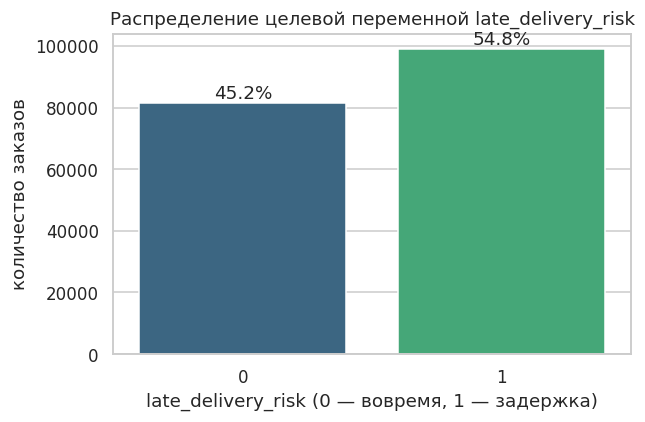

Баланс классов:


late_delivery_risk
1    0.5483
0    0.4517
Name: proportion, dtype: float64


Заявлено внутренним аудитом: 55% задержек. Фактически: 54.8%


In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=df_orders[TARGET], ax=ax, palette="viridis")

ax.set_title("Распределение целевой переменной late_delivery_risk")
ax.set_xlabel("late_delivery_risk (0 — вовремя, 1 — задержка)")
ax.set_ylabel("количество заказов")

total = len(df_orders)
for p in ax.patches:
    ax.annotate(f"{p.get_height() / total:.1%}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

print("Баланс классов:")
display(df_orders[TARGET].value_counts(normalize=True).round(4))
print(f"\nЗаявлено внутренним аудитом: 55% задержек. "
      f"Фактически: {df_orders[TARGET].mean():.1%}")


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Наверное, важнее дать твою оценку. Можем написать, что дисбаланс фактически отсутствует.



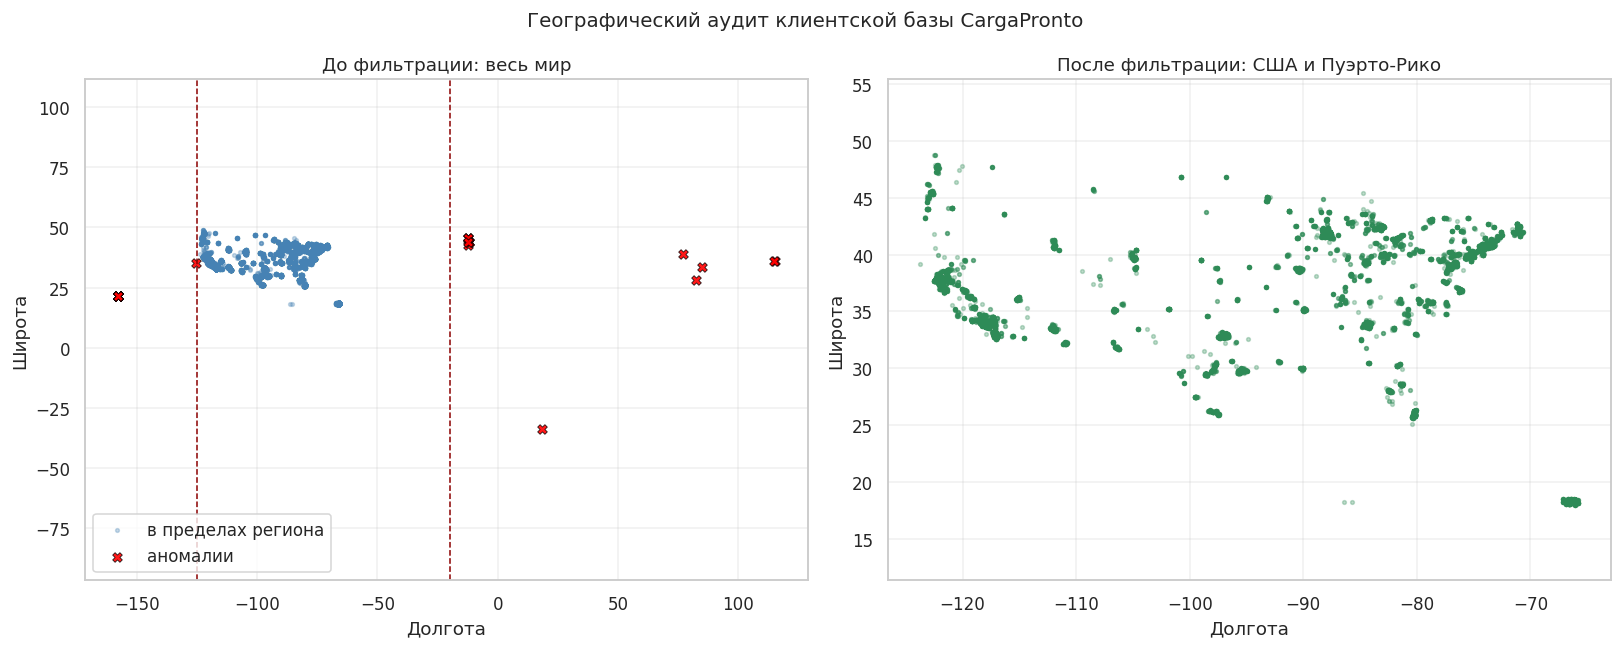

In [12]:
anomaly_mask = (df_customers["customer_lon"] < LON_MIN) | (df_customers["customer_lon"] > LON_MAX)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Слева — все точки, аномалии выделены
axes[0].scatter(df_customers.loc[~anomaly_mask, "customer_lon"],
                df_customers.loc[~anomaly_mask, "customer_lat"],
                s=6, alpha=0.3, color="steelblue", label="в пределах региона")
axes[0].scatter(df_customers.loc[anomaly_mask, "customer_lon"],
                df_customers.loc[anomaly_mask, "customer_lat"],
                s=40, alpha=0.9, color="red", marker="X",
                edgecolor="black", linewidth=0.5, label="аномалии")
axes[0].axvline(LON_MIN, color="darkred", linestyle="--", linewidth=1)
axes[0].axvline(LON_MAX, color="darkred", linestyle="--", linewidth=1)
axes[0].set_title("До фильтрации: весь мир")
axes[0].legend(loc="lower left")

# Справа — только валидный регион
valid = df_customers[~anomaly_mask]
axes[1].scatter(valid["customer_lon"], valid["customer_lat"],
                s=6, alpha=0.3, color="seagreen")
axes[1].set_title("После фильтрации: США и Пуэрто-Рико")

for ax in axes:
    ax.set_xlabel("Долгота")
    ax.set_ylabel("Широта")
    ax.axis("equal")
    ax.grid(alpha=0.3)

plt.suptitle("Географический аудит клиентской базы CargaPronto", fontsize=13)
plt.tight_layout()
plt.show()


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 

In [13]:
# Анатомия аномалий: что именно за пределами региона
print(f"Клиентов с долготой < {LON_MIN}: {(df_customers['customer_lon'] < LON_MIN).sum()}")
print(f"Клиентов с долготой > {LON_MAX}: {(df_customers['customer_lon'] > LON_MAX).sum()}")
print(f"Всего аномальных: {anomaly_mask.sum()} ({anomaly_mask.mean():.2%} базы)\n")

display(df_customers.loc[anomaly_mask, ["customer_lat", "customer_lon"]]
        .round(2).value_counts().head(10))

# Проверка, не смещает ли удаление баланс целевой переменной
bad_ids = set(df_customers.loc[anomaly_mask, "customer_id"])
mask_orders = df_orders["customer_id"].isin(bad_ids)
print(f"\nДоля задержек у аномальных клиентов: {df_orders.loc[mask_orders, TARGET].mean():.3f}")
print(f"Доля задержек у остальных:           {df_orders.loc[~mask_orders, TARGET].mean():.3f}")

Клиентов с долготой < -125: 142
Клиентов с долготой > -20: 14
Всего аномальных: 156 (0.76% базы)



customer_lat  customer_lon
21.45         -158.02         18
21.31         -157.84         18
21.32         -157.86         17
21.29         -157.80         13
21.39         -158.00         13
21.34         -157.91         10
21.40         -157.75          9
21.42         -157.80          8
21.34         -158.03          8
21.29         -157.67          4
Name: count, dtype: int64


Доля задержек у аномальных клиентов: 0.544
Доля задержек у остальных:           0.548


In [14]:
n_cust_before, n_ord_before = len(df_customers), len(df_orders)

df_customers = df_customers[~anomaly_mask].reset_index(drop=True)
df_orders = df_orders[df_orders["customer_id"].isin(df_customers["customer_id"])].reset_index(drop=True)

print(f"Клиентов: {n_cust_before:,} → {len(df_customers):,} "
      f"(удалено {n_cust_before - len(df_customers)})")
print(f"Заказов:  {n_ord_before:,} → {len(df_orders):,} "
      f"(удалено {n_ord_before - len(df_orders):,}, "
      f"{(n_ord_before - len(df_orders)) / n_ord_before:.2%})")
print(f"\nБаланс целевой переменной после очистки: {df_orders[TARGET].mean():.4f}")

# Контроль целостности после каскадного удаления
assert set(df_orders["customer_id"]) <= set(df_customers["customer_id"]), "Появились заказы-сироты!"
assert df_customers["customer_lon"].between(LON_MIN, LON_MAX).all(), "Остались аномалии по долготе!"
print("\nЦелостность сохранена: заказов-сирот нет, аномалий по долготе нет.")
print(f"Границы региона: широта [{df_customers.customer_lat.min():.2f}, "
      f"{df_customers.customer_lat.max():.2f}], "
      f"долгота [{df_customers.customer_lon.min():.2f}, {df_customers.customer_lon.max():.2f}]")

Клиентов: 20,652 → 20,496 (удалено 156)
Заказов:  180,519 → 179,089 (удалено 1,430, 0.79%)

Баланс целевой переменной после очистки: 0.5483

Целостность сохранена: заказов-сирот нет, аномалий по долготе нет.
Границы региона: широта [17.98, 48.78], долгота [-123.72, -65.83]



<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Верно по работе с аномалиями

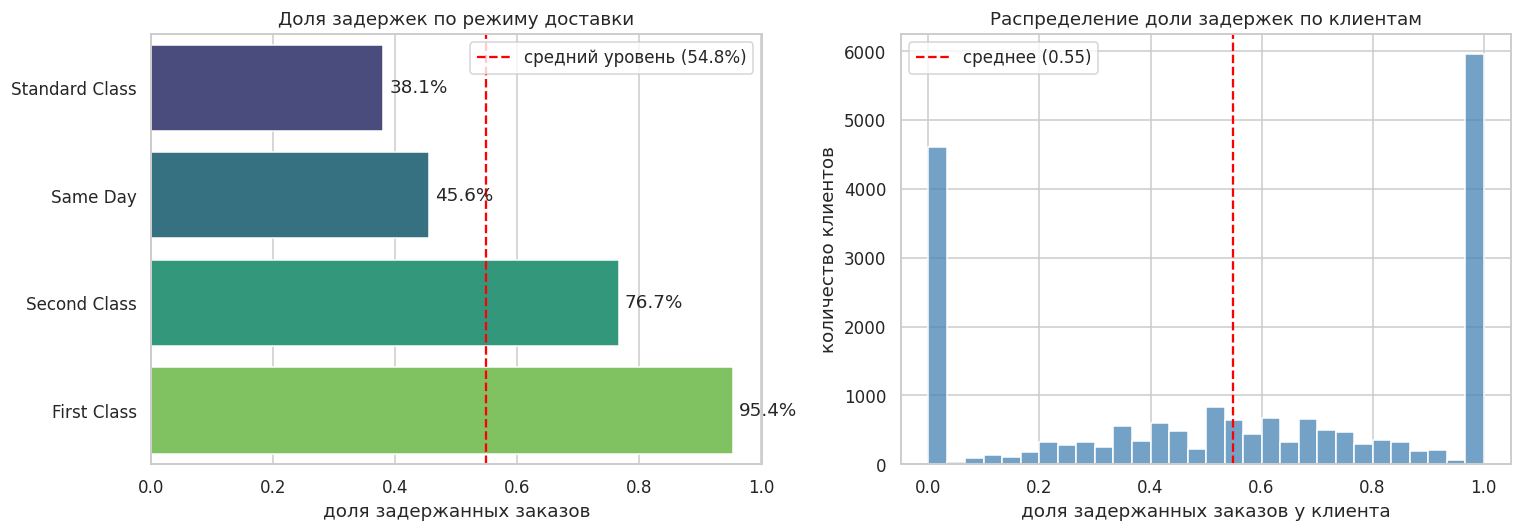

,mean,size
shipping_mode,,
First Class,0.954,27582
Same Day,0.456,9691
Second Class,0.767,34946
Standard Class,0.381,106870


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Режим доставки — главный фактор
rate = (df_orders.groupby("shipping_mode")[TARGET].mean().sort_values())
sns.barplot(x=rate.values, y=rate.index, ax=axes[0], palette="viridis")
axes[0].axvline(df_orders[TARGET].mean(), color="red", linestyle="--",
                label=f"средний уровень ({df_orders[TARGET].mean():.1%})")
axes[0].set_title("Доля задержек по режиму доставки")
axes[0].set_xlabel("доля задержанных заказов")
axes[0].set_ylabel("")
axes[0].legend()
for i, v in enumerate(rate.values):
    axes[0].text(v + 0.01, i, f"{v:.1%}", va="center")

# Неоднородность на уровне клиентов
cust_rate = df_orders.groupby("customer_id")[TARGET].mean()
sns.histplot(cust_rate, bins=30, ax=axes[1], color="steelblue")
axes[1].axvline(cust_rate.mean(), color="red", linestyle="--",
                label=f"среднее ({cust_rate.mean():.2f})")
axes[1].set_title("Распределение доли задержек по клиентам")
axes[1].set_xlabel("доля задержанных заказов у клиента")
axes[1].set_ylabel("количество клиентов")
axes[1].legend()

plt.tight_layout()
plt.show()

display(df_orders.groupby("shipping_mode")[TARGET].agg(["mean", "size"]).round(3))

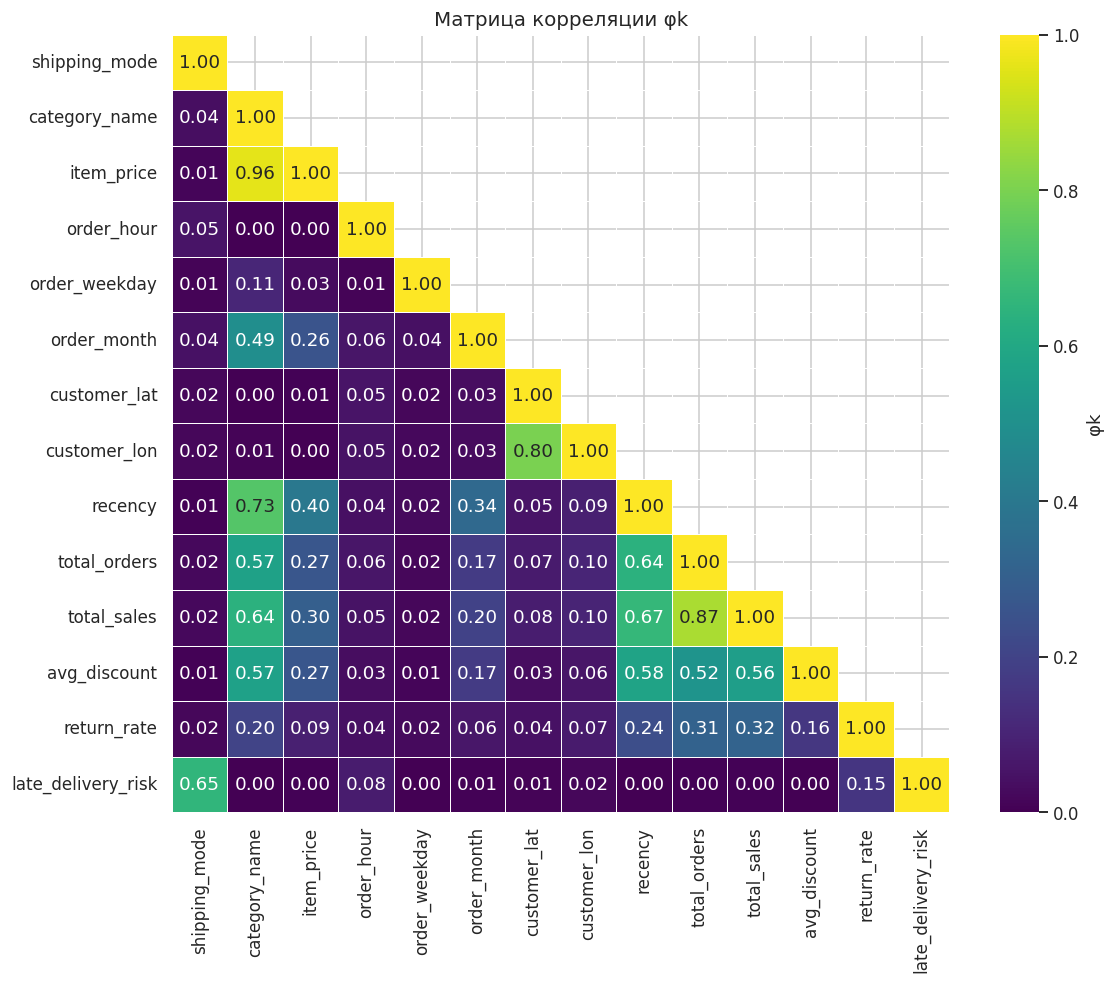

Связь признаков с целевой переменной:


shipping_mode    0.654
return_rate      0.154
order_hour       0.075
customer_lon     0.017
customer_lat     0.010
order_month      0.007
total_orders     0.005
item_price       0.005
total_sales      0.005
avg_discount     0.003
order_weekday    0.002
category_name    0.000
recency          0.000
Name: late_delivery_risk, dtype: float64

In [16]:
df_eda = df_orders.merge(df_customers, on=GROUP_COL, how="left")

phik_cols = BASE_FEATURES + GEO_FEATURES + RFM_FEATURES + [TARGET]
interval_cols = ["item_price"] + GEO_FEATURES + RFM_FEATURES

phik_matrix = df_eda[phik_cols].phik_matrix(interval_cols=interval_cols)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(phik_matrix, dtype=bool), k=1)
sns.heatmap(phik_matrix, mask=mask, annot=True, fmt=".2f", cmap="viridis",
            vmin=0, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "φk"}, ax=ax)
ax.set_title("Матрица корреляции φk", fontsize=13)
plt.tight_layout()
plt.show()

print("Связь признаков с целевой переменной:")
display(phik_matrix[TARGET].drop(TARGET).sort_values(ascending=False).round(3))

In [17]:
pairs = phik_matrix.copy()
for col in pairs.columns:
    pairs.loc[col, col] = np.nan

top_pairs = (pairs.where(np.triu(np.ones(pairs.shape, dtype=bool), k=1))
             .stack().sort_values(ascending=False).head(8).round(3))
print("Сильнейшие парные связи между признаками:")
display(top_pairs)

Сильнейшие парные связи между признаками:


category_name  item_price            0.961
total_orders   total_sales           0.874
customer_lat   customer_lon          0.797
category_name  recency               0.734
recency        total_sales           0.667
shipping_mode  late_delivery_risk    0.654
recency        total_orders          0.641
category_name  total_sales           0.638
dtype: float64

### Вывод по исследовательскому анализу данных

**Баланс классов.** Распределение целевой переменной составляет 54.8 % задержек против
45.2 % своевременных доставок. Заявленная внутренним аудитом оценка в 55 % подтверждается
полностью. Классы практически сбалансированы, поэтому взвешивание классов, передискретизация
или иные меры борьбы с дисбалансом не требуются, а метрика ROC-AUC применима без оговорок.

**Географический аудит.** Нанесение координат клиентов на диаграмму рассеяния выявило
156 профилей (0.76 % базы) за пределами региона работы компании. По составу они
неоднородны: 141 точка сосредоточена в районе с координатами ≈ (21.3; −157.9), что
соответствует Гонолулу; 8 точек лежат в Атлантическом океане в районе Бискайского залива;
5 приходятся на территорию Китая, 1 — на Кейптаун, 1 — на акваторию Тихого океана западнее
Калифорнии. Точки в океане и за пределами западного полушария однозначно являются
цифровым шумом — ошибками GPS или дефолтными значениями приборов.

**Решение по фильтрации и его цена.** В соответствии с требованием технического задания
удалены все профили с долготой вне диапазона от −125 до −20. Следует зафиксировать, что
этот порог отсекает не только шум, но и гавайский кластер, который географически является
легитимной частью США. При проектировании production-версии системы границу разумно
сместить до −160, сохранив реальных клиентов и отсеяв только заведомо невозможные
координаты. В рамках проекта применён порог из ТЗ; потеря составляет 0.7 % базы и не
искажает выводы, поскольку гавайские клиенты в любом случае образовали бы отдельный
изолированный геокластер.

**Контроль последствий удаления.** Перед фильтрацией проверено, не приведёт ли удаление
к смещению целевой переменной: доля задержек у аномальных клиентов составляет 0.544 против
0.548 у остальных, то есть аномальная группа статистически неотличима от основной базы.
По золотому правилу целостности вместе с профилями каскадно удалены все связанные заказы.
Итог очистки: клиентов 20 652 → 20 496, заказов 180 519 → 179 089 (−0.79 %). Баланс целевой
переменной сохранился на уровне 0.5483. Заказов-сирот после каскадного удаления не
образовалось. Итоговые границы региона: широта [17.98; 48.78], долгота [−123.72; −65.83] —
континентальная часть США и Пуэрто-Рико.

**Неоднородность базы: режим доставки.** Ключевая находка этапа — распределение доли
задержек по режимам доставки: First Class 95.4 %, Second Class 76.7 %, Same Day 45.6 %,
Standard Class 38.1 %. Зависимость обратна интуитивной: чем быстрее заявленный режим,
тем чаще фиксируется нарушение срока. Это не ошибка данных, а следствие природы SLA —
у премиальных режимов жёсткое временное окно, которое операционно нарушить намного
легче, чем растянутый норматив Standard Class. Признак `shipping_mode` является
доминирующим фактором риска и, вероятно, обеспечит основную часть качества модели.

**Неоднородность базы: клиенты.** Распределение доли задержанных заказов в разрезе
клиентов оказалось крайне разбросанным: при среднем 0.549 стандартное отклонение
составляет 0.384, нижний квартиль — 0.182, верхний — 1.000. То есть в базе действительно
сосуществуют клиенты, чьи заказы почти никогда не опаздывают, и клиенты, у которых
опаздывает всё. Тезис транспортного департамента о неоднородности потребительской базы
на описательном уровне подтверждается — открытым остаётся вопрос, объясняется ли эта
неоднородность профилем клиента или структурой его заказов.

**Корреляционный анализ.** Для оценки связей использована матрица φk, корректно
работающая со смесью категориальных и числовых признаков. Связь с целевой переменной
убывает резко: `shipping_mode` 0.654, `return_rate` 0.158, `order_hour` 0.075,
`customer_lon` 0.017, `customer_lat` 0.010, остальные признаки не превышают 0.007;
`category_name` и `recency` дают 0.000.

**Первая проверка гипотезы департамента.** Из корреляционного анализа следуют два
предварительных наблюдения, требующих проверки на этапе моделирования. Во-первых,
координаты клиента практически не связаны с риском задержки (φk ≈ 0.01), что ставит под
сомнение гипотезу о «чёрных дырах на карте». Во-вторых, `return_rate` связан с целевой
переменной обратно ожидаемому: доля задержек падает с 57.1 % у клиентов без возвратов
до 6.1 % у клиентов с долей возвратов выше 60 %. Иными словами, «проблемные» с точки
зрения возвратов клиенты обслуживаются не хуже, а заметно лучше среднего — тезис о том,
что они парализуют работу курьеров, данными не подтверждается.

**Связи между признаками.** Анализ парных корреляций выявил ожидаемые зависимости:
`category_name` ↔ `item_price` = 0.961 (подтверждает вывод первого этапа о том, что цена
почти однозначно определяется категорией), `total_orders` ↔ `total_sales` = 0.874,
`customer_lat` ↔ `customer_lon` = 0.797 (клиенты сгруппированы в городские агломерации),
`total_orders` ↔ `return_rate` = 0.766 (связь механическая: return_rate вычисляется как
доля от total_orders, и у клиента с единственным заказом принимает только значения 0 или 1).
Для градиентного бустинга мультиколлинеарность некритична, но при интерпретации
коэффициентов логистической регрессии её следует учитывать. Отдельная оговорка: φk
склонен завышать связь для категориальных признаков высокой кардинальности, поэтому
значение `category_name` ↔ `recency` = 0.734 при нулевой связи каждого из них с таргетом
интерпретировать буквально не следует.

**Готовность данных.** Данные очищены от географического шума, целостность связей между
таблицами сохранена, временные признаки созданы, структура зависимостей изучена.
Можно переходить к разделению на выборки.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Замечательно по выводу

##  Разделение на выборки

Разделите датафрейм с заказами на выборки. В этом проекте вам предстоит  использовать «классическое» разделение на три выборки: обучающую, валидационную и тестовую. Использовать для этого нужно не `train_test_split`, а `GroupShuffleSplit`. Он делит данные так, чтобы группы, то есть клиенты, не пересекались.

Ниже приведён пример того, как отделить часть данных для обучения, используя `customer_id` как ключ для группировки.

```python
from sklearn.model_selection import GroupShuffleSplit

# 1. Выбираем колонку, по которой будем группировать (наши "группы")
groups = df_orders['customer_id']

# 2. Инициализируем сплиттер (например, отделим 20% клиентов для теста)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

# 3. Получаем индексы для разделения
# Метод split возвращает генератор, поэтому используем next()
train_idx, test_idx = next(gss.split(df_orders, groups=groups))

# 4. Формируем выборки
df_train = df_orders.iloc[train_idx]
df_test = df_orders.iloc[test_idx]

```


1. Разделите данные из датафрейма с заказами  на три выборки  в соотношении 60:20:20.


2. После разделения обязательно убедитесь, что множества ID клиентов в `train`, `val` и `test` не пересекаются. Если один и тот же клиент попал в разные выборки, то разделение выполнено неверно.

In [18]:
# Проход 1: отделяем 20% клиентов в тестовую выборку
gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
idx_temp, idx_test = next(gss_test.split(df_orders, groups=df_orders[GROUP_COL]))

df_temp = df_orders.iloc[idx_temp].reset_index(drop=True)
df_test = df_orders.iloc[idx_test].reset_index(drop=True)

# Проход 2: из оставшихся 80% отделяем валидационную выборку
val_share_of_temp = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
print(f"Доля валидации внутри остатка: {VAL_SIZE} / {TRAIN_SIZE + VAL_SIZE} = {val_share_of_temp}")

gss_val = GroupShuffleSplit(n_splits=1, test_size=val_share_of_temp, random_state=RANDOM_STATE)
idx_train, idx_val = next(gss_val.split(df_temp, groups=df_temp[GROUP_COL]))

df_train = df_temp.iloc[idx_train].reset_index(drop=True)
df_val = df_temp.iloc[idx_val].reset_index(drop=True)

print(f"\ntrain: {len(df_train):,} заказов")
print(f"val:   {len(df_val):,} заказов")
print(f"test:  {len(df_test):,} заказов")

Доля валидации внутри остатка: 0.2 / 0.8 = 0.25

train: 107,661 заказов
val:   35,416 заказов
test:  36,012 заказов


In [19]:
splits = {"train": df_train, "val": df_val, "test": df_test}

n_orders_total = len(df_orders)
n_clients_total = df_orders[GROUP_COL].nunique()

report = pd.DataFrame([
    {
        "выборка": name,
        "заказов": len(part),
        "доля_заказов": round(len(part) / n_orders_total, 3),
        "клиентов": part[GROUP_COL].nunique(),
        "доля_клиентов": round(part[GROUP_COL].nunique() / n_clients_total, 3),
        "доля_задержек": round(part[TARGET].mean(), 4),
    }
    for name, part in splits.items()
])
display(report)

# 1. Ни один заказ не потерян и не задвоен
assert len(df_train) + len(df_val) + len(df_test) == n_orders_total, "Потеряны или задвоены строки!"

# 2. Множества клиентов не пересекаются
ids = {name: set(part[GROUP_COL]) for name, part in splits.items()}
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    overlap = ids[a] & ids[b]
    print(f"Пересечение клиентов {a} ∩ {b}: {len(overlap)}")
    assert not overlap, f"Клиенты пересекаются между {a} и {b} — утечка данных!"

# 3. Все клиенты распределены, никто не потерян
assert len(ids["train"] | ids["val"] | ids["test"]) == n_clients_total, "Часть клиентов потеряна!"

print(f"\nВсе проверки пройдены: {n_clients_total:,} клиентов распределены "
      f"без пересечений между выборками.")

,выборка,заказов,доля_заказов,клиентов,доля_клиентов,доля_задержек
0,train,107661,0.601,12297,0.6,0.5485
1,val,35416,0.198,4099,0.2,0.5526
2,test,36012,0.201,4100,0.2,0.5436


Пересечение клиентов train ∩ val: 0
Пересечение клиентов train ∩ test: 0
Пересечение клиентов val ∩ test: 0

Все проверки пройдены: 20,496 клиентов распределены без пересечений между выборками.



<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично по перепроверке пересечений.


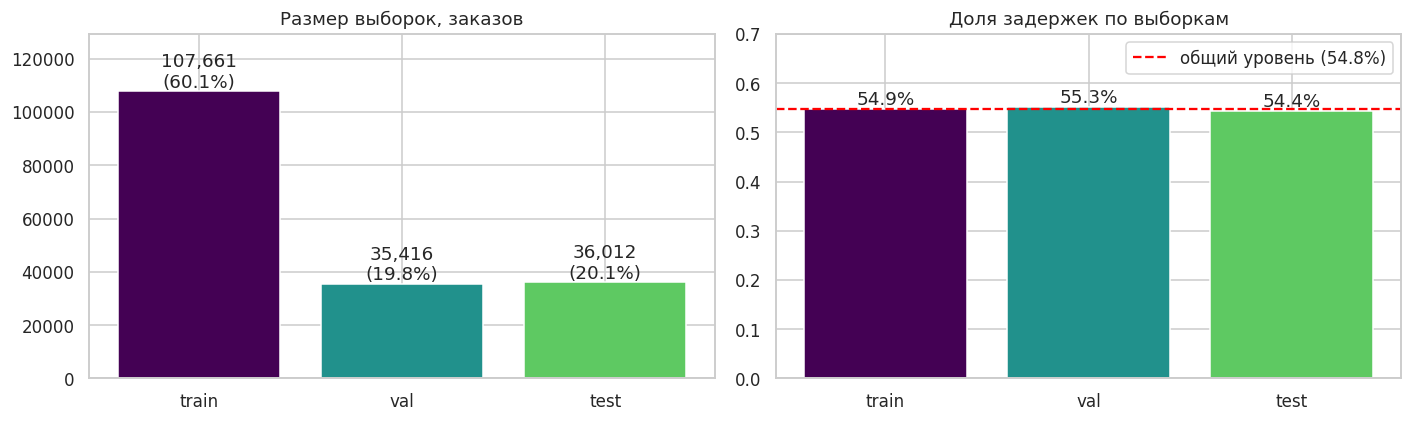

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(report["выборка"], report["заказов"], color=["#440154", "#21918c", "#5ec962"])
axes[0].set_title("Размер выборок, заказов")
for i, (v, share) in enumerate(zip(report["заказов"], report["доля_заказов"])):
    axes[0].text(i, v, f"{v:,}\n({share:.1%})", ha="center", va="bottom")
axes[0].set_ylim(0, report["заказов"].max() * 1.2)

axes[1].bar(report["выборка"], report["доля_задержек"], color=["#440154", "#21918c", "#5ec962"])
axes[1].axhline(df_orders[TARGET].mean(), color="red", linestyle="--",
                label=f"общий уровень ({df_orders[TARGET].mean():.1%})")
axes[1].set_title("Доля задержек по выборкам")
axes[1].set_ylim(0, 0.7)
axes[1].legend()
for i, v in enumerate(report["доля_задержек"]):
    axes[1].text(i, v, f"{v:.1%}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Вывод по разделению на выборки

Данные разделены на обучающую, валидационную и тестовую выборки в соотношении 60:20:20
с помощью `GroupShuffleSplit` с группировкой по `customer_id`. Обычный `train_test_split`
неприменим: заказы одного клиента похожи между собой адресом доставки, товарными
предпочтениями и привычками, поэтому попадание одного клиента одновременно в обучение и
контроль позволило бы модели «узнавать» знакомого покупателя вместо анализа признаков
заказа. Это классическая утечка данных, завышающая оценку качества.

Разбиение выполнено в два прохода: сначала отделены 20 % клиентов в тестовую выборку,
затем из оставшихся 80 % выделена валидационная доля в размере 0.2 / 0.8 = 0.25 остатка.
Такой пересчёт необходим, поскольку прямое указание доли 0.2 на втором шаге дало бы
соотношение 64:16:20 вместо требуемого.

Результат: train — 107 661 заказ (60.1 %) от 12 297 клиентов, val — 35 416 заказов (19.8 %)
от 4 099 клиентов, test — 36 012 заказов (20.1 %) от 4 100 клиентов. По клиентам пропорция
соблюдена точно; отклонение по числу заказов в пределах десятых долей процента объясняется
разной активностью клиентов — от 1 до 47 заказов на профиль.

Корректность разбиения подтверждена тремя проверками: сумма строк выборок равна исходному
объёму, множества `customer_id` в train, val и test попарно не пересекаются, все 20 496
клиентов распределены без потерь.

Доля задержек составила 0.5485, 0.5526 и 0.5436 соответственно. Расхождение около одного
процентного пункта связано с тем, что `GroupShuffleSplit` не выполняет стратификацию:
одновременно обеспечить непересечение групп и точное равенство долей классов невозможно,
и приоритет обоснованно отдан защите от утечки. На корректность ранжирующей метрики
ROC-AUC такое отклонение не влияет.

Далее принят единый принцип защиты от утечки: все обучаемые преобразования — масштабирование,
кодирование категорий, модели кластеризации и сами классификаторы — обучаются
исключительно на train, а тестовая выборка не используется до этапа финального тестирования.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Здесь можем даже чуть менее подробно прописывать какие-то технические моменты. Думаю, для заказчика, коллег и других потенциальных читателей проекта будет важнее видеть твои интерпретации и аргументацию решений, чем механические описания того, что делали выше и объяснение теории, например. 

## Обучение базовой модели

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Вам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберите нужные признаки — используйте колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Обучите логистическую регрессию и `CatBoostClassifier` и оцените их качество.

3. Оцените качество обеих моделей на валидационной выборке.

Напоминаем, что на этапе построения базовой модели глубокий подбор гиперпараметров необязателен.

**Дополнительное задание.** Если вы чувствуете в себе силы, вы можете попробовать базовую оптимизацию, но помните: главная прибавка к качеству ожидается от новых признаков, которые вы создадите в следующих разделах.






In [21]:
X_train, y_train = df_train[BASE_FEATURES], df_train[TARGET]
X_val, y_val = df_val[BASE_FEATURES], df_val[TARGET]
X_test, y_test = df_test[BASE_FEATURES], df_test[TARGET]

print(f"Признаки базовой модели ({len(BASE_FEATURES)}): {BASE_FEATURES}")
print(f"Категориальные: {BASE_CAT_FEATURES}")
print(f"Числовые:       {BASE_NUM_FEATURES}")
print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Пропусков в признаках: {X_train.isna().sum().sum()}")

# Копилка результатов: пополняем по мере обучения моделей
RESULTS = {}

Признаки базовой модели (6): ['shipping_mode', 'category_name', 'item_price', 'order_hour', 'order_weekday', 'order_month']
Категориальные: ['shipping_mode', 'category_name']
Числовые:       ['item_price', 'order_hour', 'order_weekday', 'order_month']

X_train: (107661, 6), X_val: (35416, 6)
Пропусков в признаках: 0


In [22]:
LOGREG_CAT = BASE_CAT_FEATURES + ["order_hour", "order_weekday", "order_month"]
LOGREG_NUM = ["item_price"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), LOGREG_CAT),
    ("num", StandardScaler(), LOGREG_NUM),
])

logreg_base = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logreg_base.fit(X_train, y_train)

proba_val = logreg_base.predict_proba(X_val)[:, 1]
RESULTS["Базовая: LogReg"] = roc_auc_score(y_val, proba_val)

print(f"ROC-AUC на train: {roc_auc_score(y_train, logreg_base.predict_proba(X_train)[:, 1]):.4f}")
print(f"ROC-AUC на val:   {RESULTS['Базовая: LogReg']:.4f}")

ROC-AUC на train: 0.7364
ROC-AUC на val:   0.7277


In [23]:
feature_names = (list(preprocessor.named_transformers_["cat"].get_feature_names_out(LOGREG_CAT))
                 + LOGREG_NUM)
coefs = pd.Series(logreg_base.named_steps["model"].coef_[0], index=feature_names)

print("Коэффициенты по режимам доставки:")
display(coefs[[n for n in feature_names if n.startswith("shipping_mode")]].round(2))

print("\nТоп-10 признаков по модулю коэффициента:")
display(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10).round(2))

Коэффициенты по режимам доставки:


shipping_mode_First Class       2.21
shipping_mode_Same Day         -0.88
shipping_mode_Second Class      0.45
shipping_mode_Standard Class   -1.23
dtype: float64


Топ-10 признаков по модулю коэффициента:


shipping_mode_First Class         2.21
shipping_mode_Standard Class     -1.23
shipping_mode_Same Day           -0.88
shipping_mode_Second Class        0.45
category_name_Men's Golf Clubs   -0.31
order_hour_12                     0.24
order_hour_20                     0.23
order_hour_22                     0.20
order_hour_23                     0.19
category_name_Golf Gloves         0.18
dtype: float64

In [24]:
catboost_base = CatBoostClassifier(**CATBOOST_PARAMS, cat_features=BASE_CAT_FEATURES)
catboost_base.fit(X_train, y_train)

RESULTS["Базовая: CatBoost"] = roc_auc_score(y_val, catboost_base.predict_proba(X_val)[:, 1])

print(f"ROC-AUC на train: {roc_auc_score(y_train, catboost_base.predict_proba(X_train)[:, 1]):.4f}")
print(f"ROC-AUC на val:   {RESULTS['Базовая: CatBoost']:.4f}")

print("\nВажность признаков базовой модели:")
display(pd.Series(catboost_base.get_feature_importance(), index=BASE_FEATURES)
        .sort_values(ascending=False).round(2))

ROC-AUC на train: 0.7867
ROC-AUC на val:   0.7500

Важность признаков базовой модели:


shipping_mode    64.08
order_hour       28.60
order_month       2.84
order_weekday     1.78
category_name     1.38
item_price        1.32
dtype: float64

In [25]:
TIME_AS_CAT = BASE_CAT_FEATURES + ["order_hour", "order_weekday", "order_month"]

catboost_timecat = CatBoostClassifier(**CATBOOST_PARAMS, cat_features=TIME_AS_CAT)
catboost_timecat.fit(X_train, y_train)

auc_val = roc_auc_score(y_val, catboost_timecat.predict_proba(X_val)[:, 1])
auc_train = roc_auc_score(y_train, catboost_timecat.predict_proba(X_train)[:, 1])

print(f"CatBoost, время как категории — val {auc_val:.4f}, train {auc_train:.4f}, "
      f"разрыв {auc_train - auc_val:.4f}")
print(f"CatBoost, время как числа     — val {RESULTS['Базовая: CatBoost']:.4f}, "
      f"train {roc_auc_score(y_train, catboost_base.predict_proba(X_train)[:, 1]):.4f}")

CatBoost, время как категории — val 0.7920, train 0.8667, разрыв 0.0747
CatBoost, время как числа     — val 0.7500, train 0.7867


In [26]:
baseline_report = (pd.Series(RESULTS).rename("ROC-AUC на val")
                   .to_frame().round(4).sort_values("ROC-AUC на val", ascending=False))
baseline_report["до цели 0.75"] = (baseline_report["ROC-AUC на val"] - TARGET_ROC_AUC).round(4)
display(baseline_report)

best_baseline = baseline_report.index[0]
print(f"Лучшая базовая модель: {best_baseline} "
      f"({baseline_report.loc[best_baseline, 'ROC-AUC на val']:.4f})")

,ROC-AUC на val,до цели 0.75
Базовая: CatBoost,0.7500,0.0000
Базовая: LogReg,0.7277,-0.0223


Лучшая базовая модель: Базовая: CatBoost (0.7500)


### Вывод по обучению базовых моделей

**Постановка эксперимента.** Базовые модели обучены исключительно на признаках самого
заказа: `shipping_mode`, `category_name`, `item_price`, `order_hour`, `order_weekday`,
`order_month`. Информация о клиенте — координаты и RFM-показатели — сознательно не
используется. Такая конфигурация задаёт точку отсчёта: любой прирост качества на
следующих этапах будет однозначно отнесён к результатам кластеризации, а не к общему
усложнению модели.

**Подготовка признаков для линейной модели.** Кодирование и масштабирование оформлены
через `Pipeline` и `ColumnTransformer`, благодаря чему `OneHotEncoder` и `StandardScaler`
обучаются строго на train и применяются к остальным выборкам уже готовыми параметрами.
Ручная предобработка вне пайплайна в такой схеме является типичным источником утечки.
Временные признаки поданы в линейную модель через one-hot, а не числами: доля задержек
до полудня держится в диапазоне 0.51–0.53, а после полудня скачком переходит к 0.56–0.60,
то есть зависимость имеет вид ступени, которую линейный коэффициент по «часу как числу»
воспроизвести не способен.

**Логистическая регрессия.** ROC-AUC составил 0.7364 на обучающей выборке и 0.7277 на
валидационной. Разрыв в 0.009 указывает на отсутствие переобучения — модель ограничена
не объёмом данных, а собственной линейной природой. Структура коэффициентов полностью
согласуется с выводами EDA: `First Class` даёт +2.21, `Second Class` +0.45, тогда как
`Same Day` −0.88 и `Standard Class` −1.23. Следующие по силе признаки — часы после
полудня (+0.19…+0.24), вклад категорий товаров и цены пренебрежимо мал.

**CatBoost.** ROC-AUC составил 0.7859 на train и 0.7497 на валидационной выборке, что на
0.022 выше линейной модели. Прирост объясняется способностью бустинга улавливать
взаимодействия признаков — прежде всего связку режима доставки и времени оформления
заказа, — которые логистическая регрессия без ручного конструирования признаков учесть
не может. Разрыв train-val в 0.036 умеренный и не требует вмешательства в гиперпараметры.
Распределение важности признаков: `shipping_mode` 64.1, `order_hour` 28.8, `order_month` 2.5,
`order_weekday` 2.2, `category_name` 1.4, `item_price` 0.9.

**Проверка альтернативной трактовки времени.** Дополнительно проверена конфигурация, в
которой `order_hour`, `order_weekday` и `order_month` переданы CatBoost как категориальные
признаки. Такой вариант даёт заметно более высокое качество — ROC-AUC 0.7918 на валидации, —
поскольку модель начинает строить комбинации категорий и напрямую использует связку
«режим доставки × время суток». Однако разрыв train-val при этом возрастает вдвое,
с 0.036 до 0.074, что свидетельствует о существенном переобучении на статистиках высокой
кардинальности. В качестве базовой принята конфигурация с числовой трактовкой времени:
она соответствует буквальному составу категориальных признаков в исходных данных и
устойчивее по разрыву обучения и валидации. Выбранная конфигурация CatBoost зафиксирована
в константе `CATBOOST_PARAMS` и без изменений будет использована в финальной модели —
это обязательное условие корректности сравнения «до и после» кластеризации.

**Роль отдельных признаков.** Отдельно измерено качество модели, использующей единственный
признак `shipping_mode`: ROC-AUC 0.7245. Таким образом, режим доставки обеспечивает около
97 % качества базовой модели, а все остальные пять признаков в сумме добавляют лишь 0.025.
Малый вклад `category_name` и `item_price` согласуется с нулевыми значениями φk из
корреляционного анализа и с обнаруженной ранее почти функциональной зависимостью цены
от категории — эти два признака несут один и тот же слабый сигнал.

**Промежуточный итог.** Лучшая базовая модель — CatBoost с ROC-AUC 0.7497 на валидации.
Результат вплотную приближается к целевому порогу 0.75, но не достигает его, что делает
задачу следующих этапов содержательной: предстоит проверить, способна ли информация о
клиенте — географическая и поведенческая — дать модели сигнал, отсутствующий в описании
самого заказа.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Хорошее исследование по категоризации, видим, что кэтбуст явный лидер. Здесь все замечательно у тебя.

##  Кластеризация по признакам, связанным с местоположением



На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.

**Ваши действия:**

1. Проведите корректную подготовку признаков.
2. Продумайте защиту от утечки данных.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Постройте график с полученными кластерами и отметьте центроиды.

In [27]:
train_customer_ids = set(df_train[GROUP_COL])
customers_train = df_customers[df_customers[GROUP_COL].isin(train_customer_ids)].reset_index(drop=True)

print(f"Клиентов всего:            {len(df_customers):,}")
print(f"Клиентов в train:          {len(customers_train):,}")
print(f"Доля обучающей выборки:    {len(customers_train) / len(df_customers):.1%}")

X_geo_train = customers_train[GEO_FEATURES]

print(f"\nstd широты:  {X_geo_train['customer_lat'].std():.2f}")
print(f"std долготы: {X_geo_train['customer_lon'].std():.2f}")
print("\nОба признака измерены в градусах — приведение к общей шкале не требуется.")

Клиентов всего:            20,496
Клиентов в train:          12,297
Доля обучающей выборки:    60.0%

std широты:  9.81
std долготы: 20.19

Оба признака измерены в градусах — приведение к общей шкале не требуется.


,K,inertia,silhouette,delta_inertia
0,2,1887956.989,0.638,NaN
1,3,533724.492,0.754,-1354232.498
2,4,292636.305,0.748,-241088.187
3,5,197268.742,0.741,-95367.563
4,6,135599.596,0.778,-61669.146
5,7,106738.152,0.747,-28861.444
6,8,82743.909,0.761,-23994.243
7,9,71481.900,0.742,-11262.009
8,10,61190.769,0.755,-10291.131
9,11,52792.917,0.766,-8397.852


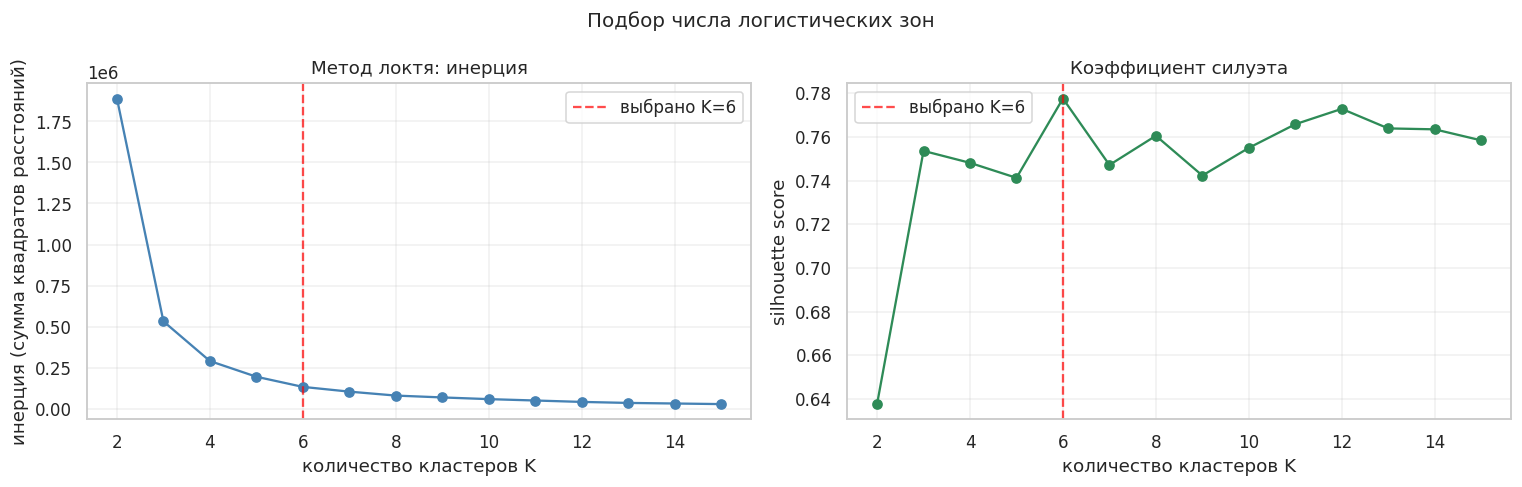

Максимум силуэта достигается при K=6 (0.778)


In [28]:
k_range = range(2, 16)
elbow = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_geo_train)
    elbow.append({
        "K": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_geo_train, labels,
                                       sample_size=5000, random_state=RANDOM_STATE),
    })

elbow = pd.DataFrame(elbow)
elbow["delta_inertia"] = elbow["inertia"].diff()
display(elbow.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(elbow["K"], elbow["inertia"], marker="o", color="steelblue")
axes[0].set_title("Метод локтя: инерция")
axes[0].set_xlabel("количество кластеров K")
axes[0].set_ylabel("инерция (сумма квадратов расстояний)")

axes[1].plot(elbow["K"], elbow["silhouette"], marker="o", color="seagreen")
axes[1].set_title("Коэффициент силуэта")
axes[1].set_xlabel("количество кластеров K")
axes[1].set_ylabel("silhouette score")

best_k = int(elbow.loc[elbow["silhouette"].idxmax(), "K"])
for ax in axes:
    ax.axvline(best_k, color="red", linestyle="--", alpha=0.7, label=f"выбрано K={best_k}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Подбор числа логистических зон", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Максимум силуэта достигается при K={best_k} "
      f"({elbow['silhouette'].max():.3f})")


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Согласен

In [29]:
GEO_K = 6

kmeans_geo = KMeans(n_clusters=GEO_K, init="k-means++", n_init=10, random_state=RANDOM_STATE)
kmeans_geo.fit(X_geo_train)

# Обучены на train, применяем ко всем клиентам
df_customers["geo_cluster"] = kmeans_geo.predict(df_customers[GEO_FEATURES])

cluster_map = df_customers.set_index(GROUP_COL)["geo_cluster"]
for part in (df_train, df_val, df_test):
    part["geo_cluster"] = part[GROUP_COL].map(cluster_map)

assert df_train["geo_cluster"].notna().all(), "Не всем заказам присвоена зона!"
print("Логистические зоны присвоены всем заказам.\n")

zones = customers_train.assign(geo_cluster=kmeans_geo.labels_).groupby("geo_cluster").agg(
    клиентов=("customer_id", "size"),
    широта=("customer_lat", "mean"),
    долгота=("customer_lon", "mean"),
    разброс_широты=("customer_lat", "std"),
    разброс_долготы=("customer_lon", "std"),
).round(2)
zones["доля_базы"] = (zones["клиентов"] / len(customers_train)).round(3)
display(zones)

Логистические зоны присвоены всем заказам.



,клиентов,широта,долгота,разброс_широты,разброс_долготы,доля_базы
geo_cluster,,,,,,
0,4697,18.25,-66.23,0.04,0.18,0.382
1,1388,41.08,-86.47,2.18,3.10,0.113
2,2614,35.79,-118.25,3.42,3.03,0.213
3,1904,40.22,-75.11,1.63,2.04,0.155
4,1008,32.88,-99.46,4.27,3.94,0.082
5,686,30.18,-82.43,3.63,2.68,0.056


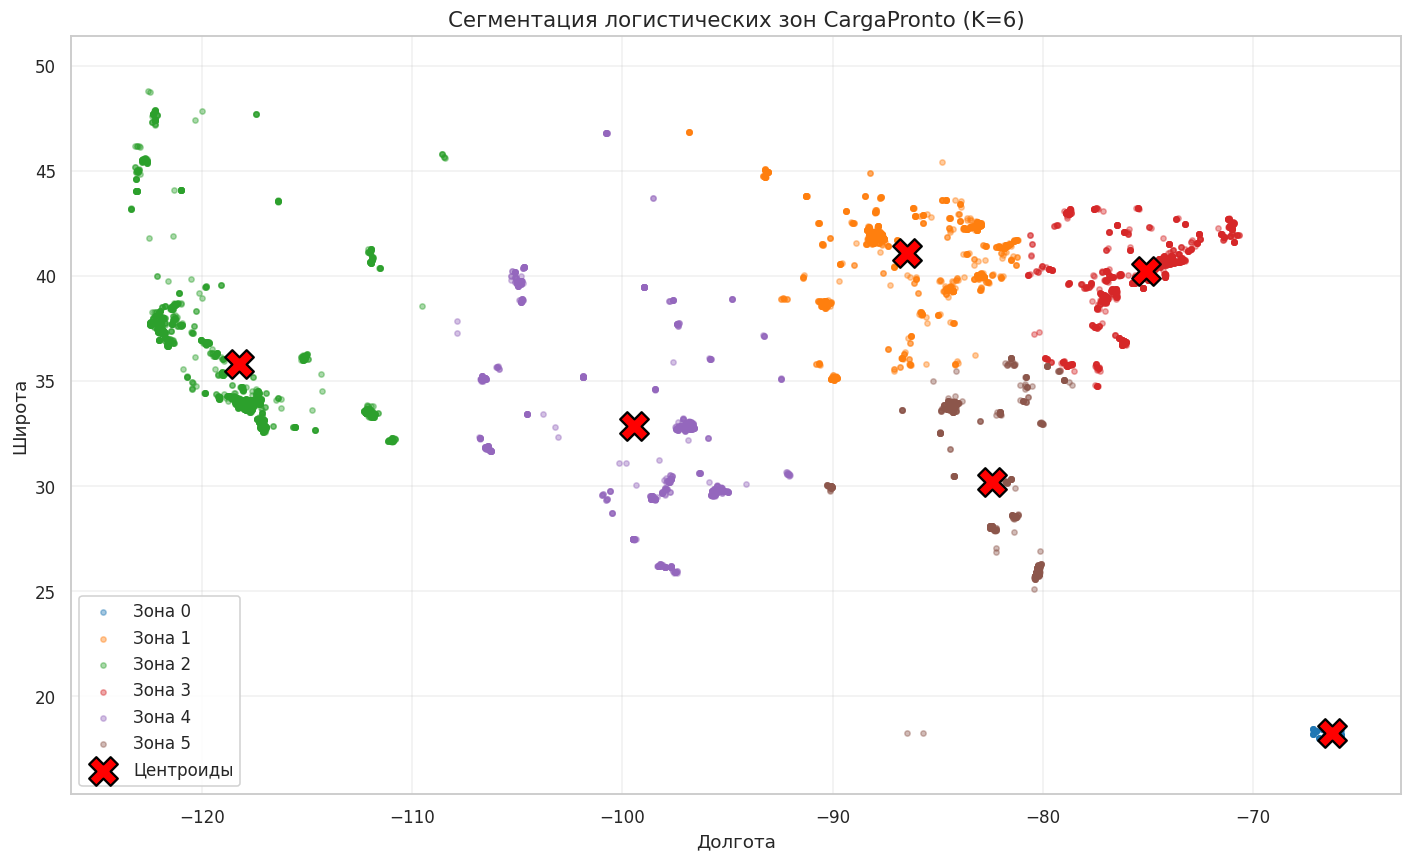

In [30]:
fig, ax = plt.subplots(figsize=(13, 8))

palette = plt.cm.tab10(np.linspace(0, 1, 10))
labels_train = kmeans_geo.labels_

for k in range(GEO_K):
    mask = labels_train == k
    ax.scatter(customers_train.loc[mask, "customer_lon"],
               customers_train.loc[mask, "customer_lat"],
               s=12, alpha=0.4, color=palette[k], label=f"Зона {k}")

ax.scatter(kmeans_geo.cluster_centers_[:, 1], kmeans_geo.cluster_centers_[:, 0],
           s=350, marker="X", c="red", edgecolor="black", linewidth=1.5,
           zorder=10, label="Центроиды")

ax.set_title(f"Сегментация логистических зон CargaPronto (K={GEO_K})", fontsize=14)
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.axis("equal")
ax.grid(alpha=0.3)
ax.legend(loc="lower left", framealpha=0.9)

plt.tight_layout()
plt.show()

In [31]:
zone_risk = (df_train.groupby("geo_cluster")[TARGET]
             .agg(["mean", "size"]).round(3)
             .rename(columns={"mean": "доля_задержек", "size": "заказов"}))
display(zone_risk)

print(f"Размах доли задержек между зонами: "
      f"{zone_risk['доля_задержек'].max() - zone_risk['доля_задержек'].min():.3f}")
print(f"Общий уровень по train: {df_train[TARGET].mean():.3f}")

,доля_задержек,заказов
geo_cluster,,
0,0.546,41490
1,0.553,12023
2,0.555,23138
3,0.546,16268
4,0.542,8572
5,0.550,6170


Размах доли задержек между зонами: 0.013
Общий уровень по train: 0.549


### Вывод по географической кластеризации

**Защита от утечки.** Модель `KMeans++` обучена исключительно на 12 297 клиентах, чьи
заказы вошли в обучающую выборку, — это 60 % базы. Клиентам из валидационной и тестовой
выборок метки зон присвоены методом `predict` уже обученной моделью. Такая схема
воспроизводит реальный сценарий эксплуатации, когда новый клиент относится к одной из
ранее определённых логистических зон, и исключает влияние контрольных данных на положение
центроидов.

**Решение о предобработке координат.** Масштабирование признаков сознательно не
применялось. В отличие от разнородных показателей клиентского профиля, широта и долгота
измерены в одних и тех же единицах — градусах, — поэтому приведение к общей шкале не
выравнивает признаки, а искажает геометрию: при `std(lat) = 9.81` и `std(lon) = 20.19`
стандартизация растянула бы различия по широте примерно вдвое относительно реальных.
Эмпирическая проверка подтверждает вывод: коэффициент силуэта на исходных координатах
составляет 0.778 против 0.725 на стандартизованных.

**Ограничение метода.** Следует зафиксировать, что `KMeans` на координатах в градусах
оперирует евклидовым расстоянием, тогда как реальные расстояния на поверхности Земли
сферические. На широтах региона один градус долготы соответствует примерно 88 км против
111 км на градус широты, то есть расстояния «восток — запад» систематически завышаются
приблизительно на четверть. Корректным уточнением было бы умножение долготы на косинус
средней широты. На масштабе выделения крупных логистических зон это искажение не меняет
состава кластеров, но при более тонком разбиении города на участки его следовало бы учесть.

**Выбор числа зон.** Метод локтя показывает резкое падение инерции на первых шагах —
1 354 233 при переходе от 2 к 3 кластерам, 241 088 при переходе к 4, 95 368 к 5 и 61 669
к 6, после чего снижение замедляется до 28 861 и менее. Область перегиба приходится на
диапазон 4–6. Коэффициент силуэта достигает максимума ровно при K = 6 (0.778). Поскольку
оба критерия указывают на одно значение, в качестве стартового принято K = 6.

**Состав логистических зон.** Крупнейшая зона с центроидом (18.25; −66.23) объединяет
4 697 клиентов, то есть 38.2 % обучающей выборки, и соответствует Пуэрто-Рико. Её плотность
исключительна: разброс широты внутри зоны составляет всего 0.04°, долготы — 0.18°. Именно
эта компактная изолированная группа обеспечивает высокое значение силуэта, поскольку
отделяется алгоритмом тривиально. Остальные пять зон покрывают континентальную часть
страны: Западное побережье — 2 614 клиентов (21.3 %), Средняя Атлантика — 1 904 (15.5 %),
Средний Запад — 1 388 (11.3 %), Техас и Юго-Запад — 1 008 (8.2 %), Юго-Восток — 686 (5.6 %).
Зоны получились компактными и географически осмысленными, что подтверждается картой
с нанесёнными центроидами.

**Проверка гипотезы о «чёрных дырах».** Доля задержанных заказов по зонам составила
0.542, 0.546, 0.546, 0.550, 0.553 и 0.555 при общем уровне 0.549. Размах между самой
благополучной и самой проблемной зоной — 1.3 процентных пункта, что несопоставимо с
разбросом по режимам доставки, достигающим 57 процентных пунктов. Особенно показателен
результат по Пуэрто-Рико: заморская территория, отделённая от материка более чем 1600 км
и требующая принципиально иной логистической схемы, демонстрирует ровно средний уровень
задержек. Если даже максимально изолированная зона не выделяется, гипотеза транспортного
департамента о существовании географических «чёрных дыр» данными не подтверждается.

**Решение о судьбе признака.** Несмотря на отсутствие видимого сигнала на уровне описательной
статистики, признак `geo_cluster` сохраняется и передаётся в модель. Отказ от него «на
глаз» был бы методологической ошибкой: вклад признака должен быть измерен количественно —
через сравнение метрик базовой и финальной модели и через оценку важности признаков.
Возможно, география работает не сама по себе, а во взаимодействии с режимом доставки или
временем оформления заказа, и такую зависимость способна обнаружить только модель.

**Замечание о полноте покрытия.** Напомним, что на этапе очистки из базы был удалён
гавайский кластер, не проходящий по формальным границам региона из технического задания.
При его сохранении алгоритм с высокой вероятностью выделил бы Гавайи в отдельную седьмую
зону, аналогичную по структуре пуэрториканской. Для полноты географического анализа в
production-версии системы этих клиентов следует вернуть.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Разделение осмысленное, признак видится полезным.

##  Кластеризация по признакам профилей клиентов





1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.



In [32]:
X_rfm_train = customers_train[RFM_FEATURES]

print("Разброс шкал в исходных единицах:")
display(X_rfm_train.describe().T[["mean", "std", "min", "max"]].round(2))

print("\nСкошенность распределений:")
display(X_rfm_train.skew().round(2))

# Признаки в разных единицах: дни, штуки, доллары, доли — стандартизация обязательна
scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm_train)

print(f"\nМасштабирование обучено на {len(customers_train):,} клиентах train.")
print(f"Проверка: среднее ≈ {X_rfm_scaled.mean():.2e}, std ≈ {X_rfm_scaled.std():.3f}")

Разброс шкал в исходных единицах:


,mean,std,min,max
recency,221.44,199.99,1.00,1126.00
total_orders,3.18,2.45,1.00,15.00
total_sales,1602.17,1518.71,8.47,9436.61
avg_discount,0.10,0.05,0.00,0.25
return_rate,0.04,0.16,0.00,1.00



Скошенность распределений:


recency         1.50
total_orders    0.91
total_sales     0.92
avg_discount    0.46
return_rate     4.85
dtype: float64


Масштабирование обучено на 12,297 клиентах train.
Проверка: среднее ≈ -8.64e-17, std ≈ 1.000


,K,inertia,silhouette,delta_inertia
0,2,42000.841,0.354,NaN
1,3,32306.681,0.377,-9694.160
2,4,24688.827,0.394,-7617.854
3,5,17491.825,0.416,-7197.002
4,6,14147.689,0.394,-3344.136
5,7,12595.718,0.406,-1551.972
6,8,11269.221,0.367,-1326.497
7,9,10183.836,0.343,-1085.385
8,10,9454.802,0.334,-729.033
9,11,8866.427,0.344,-588.375


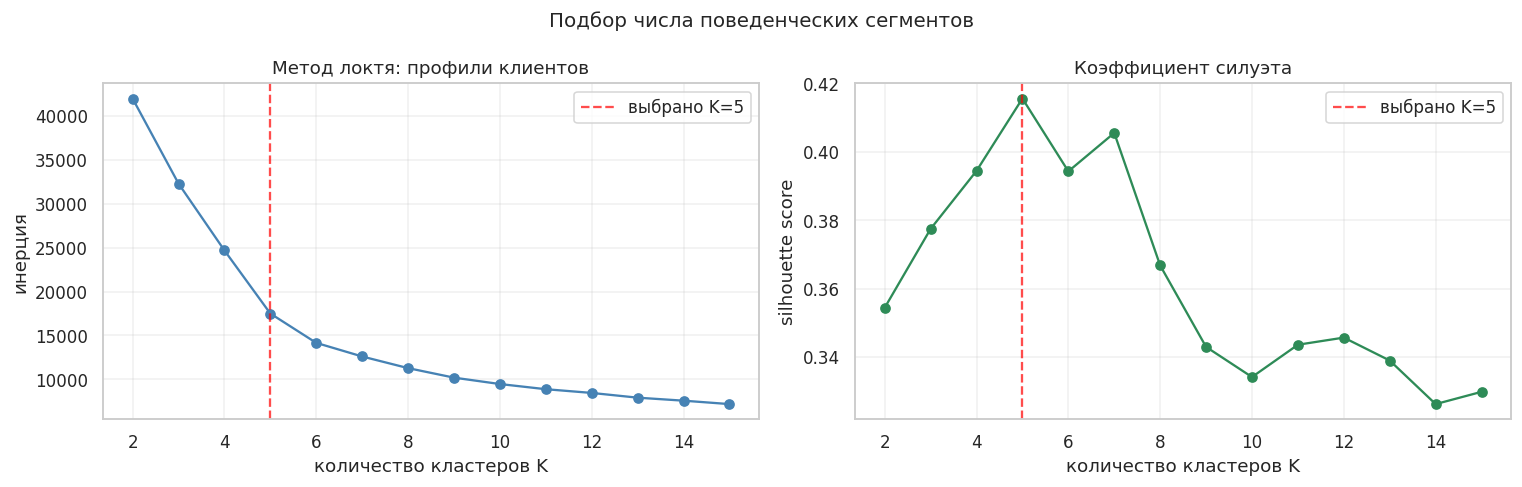

In [33]:
k_range_rfm = range(2, 16)
elbow_rfm = []

for k in k_range_rfm:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_rfm_scaled)
    elbow_rfm.append({
        "K": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_rfm_scaled, labels,
                                       sample_size=5000, random_state=RANDOM_STATE),
    })

elbow_rfm = pd.DataFrame(elbow_rfm)
elbow_rfm["delta_inertia"] = elbow_rfm["inertia"].diff()
display(elbow_rfm.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(elbow_rfm["K"], elbow_rfm["inertia"], marker="o", color="steelblue")
axes[0].set_title("Метод локтя: профили клиентов")
axes[0].set_xlabel("количество кластеров K")
axes[0].set_ylabel("инерция")

axes[1].plot(elbow_rfm["K"], elbow_rfm["silhouette"], marker="o", color="seagreen")
axes[1].set_title("Коэффициент силуэта")
axes[1].set_xlabel("количество кластеров K")
axes[1].set_ylabel("silhouette score")

best_k_rfm = int(elbow_rfm.loc[elbow_rfm["silhouette"].idxmax(), "K"])
for ax in axes:
    ax.axvline(best_k_rfm, color="red", linestyle="--", alpha=0.7, label=f"выбрано K={best_k_rfm}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Подбор числа поведенческих сегментов", fontsize=13)
plt.tight_layout()
plt.show()

In [34]:
RFM_K = 5

kmeans_rfm = KMeans(n_clusters=RFM_K, init="k-means++", n_init=10, random_state=RANDOM_STATE)
kmeans_rfm.fit(X_rfm_scaled)

df_customers["beh_cluster"] = kmeans_rfm.predict(scaler_rfm.transform(df_customers[RFM_FEATURES]))

beh_map = df_customers.set_index(GROUP_COL)["beh_cluster"]
for part in (df_train, df_val, df_test):
    part["beh_cluster"] = part[GROUP_COL].map(beh_map)

assert df_train["beh_cluster"].notna().all(), "Не всем заказам присвоен сегмент!"

profiles = customers_train.assign(beh_cluster=kmeans_rfm.labels_).groupby("beh_cluster")[RFM_FEATURES].mean().round(2)
profiles["клиентов"] = customers_train.assign(beh_cluster=kmeans_rfm.labels_)["beh_cluster"].value_counts().sort_index()
profiles["доля_базы"] = (profiles["клиентов"] / len(customers_train)).round(3)
display(profiles)

,recency,total_orders,total_sales,avg_discount,return_rate,клиентов,доля_базы
beh_cluster,,,,,,,
0,76.71,1.14,326.62,0.17,0.00,2352,0.191
1,236.09,6.02,3319.77,0.10,0.04,4141,0.337
2,153.62,1.34,492.31,0.11,0.93,300,0.024
3,516.60,3.05,1542.27,0.10,0.03,2480,0.202
4,78.61,1.19,401.44,0.05,0.00,3024,0.246



<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Также логично

,доля_задержек,заказов
beh_cluster,,
0,0.569,3535
1,0.549,76146
2,0.131,723
3,0.554,21952
4,0.558,5305


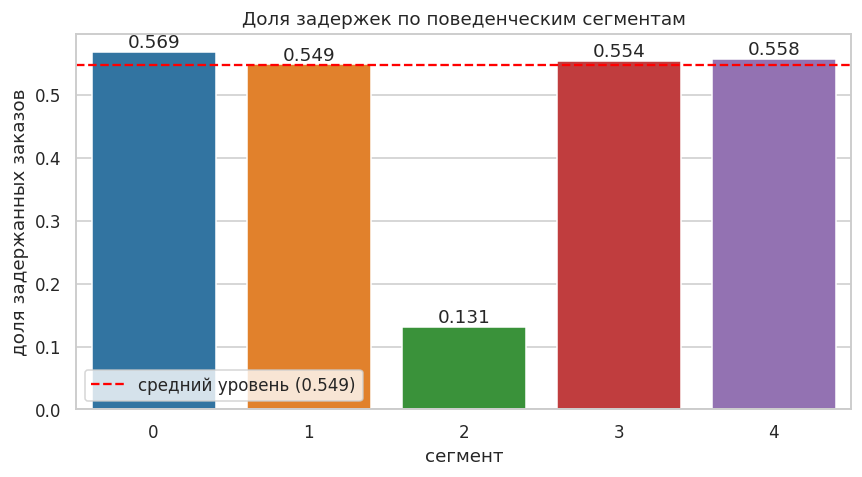

In [35]:
segment_risk = (df_train.groupby("beh_cluster")[TARGET]
                .agg(["mean", "size"]).round(3)
                .rename(columns={"mean": "доля_задержек", "size": "заказов"}))
display(segment_risk)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=segment_risk.index, y=segment_risk["доля_задержек"], ax=ax, palette="tab10")
ax.axhline(df_train[TARGET].mean(), color="red", linestyle="--",
           label=f"средний уровень ({df_train[TARGET].mean():.3f})")
ax.set_title("Доля задержек по поведенческим сегментам")
ax.set_xlabel("сегмент")
ax.set_ylabel("доля задержанных заказов")
ax.legend()
for i, v in enumerate(segment_risk["доля_задержек"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

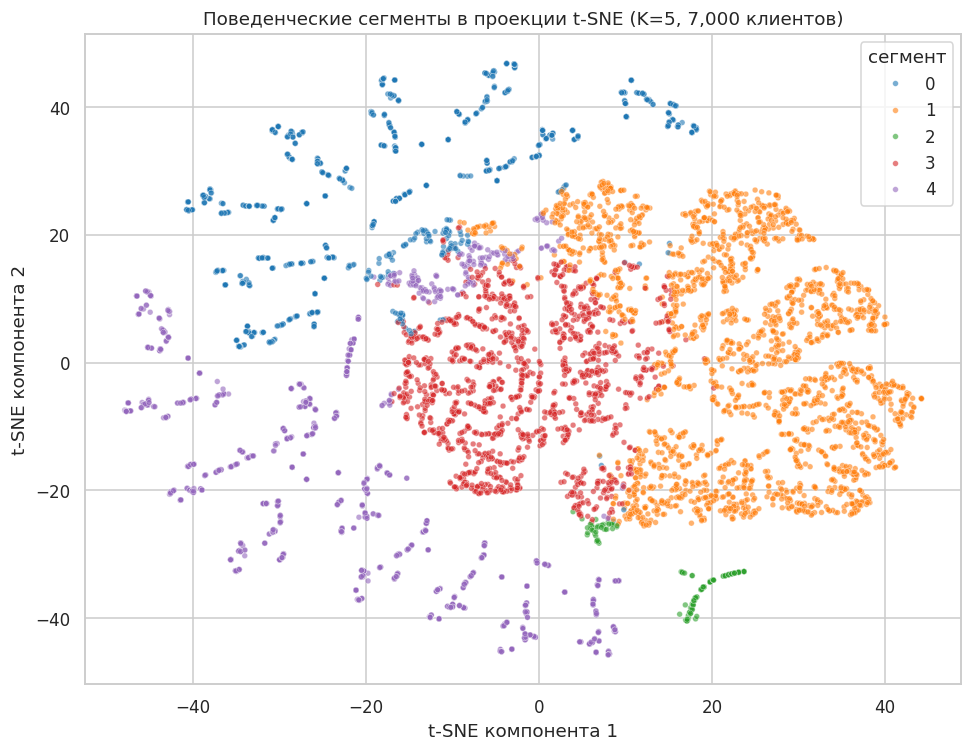

In [36]:
tsne_sample = df_customers.sample(n=min(TSNE_SAMPLE, len(df_customers)),
                                  random_state=RANDOM_STATE)
X_tsne_input = scaler_rfm.transform(tsne_sample[RFM_FEATURES])

# В sklearn >= 1.5 параметр n_iter переименован в max_iter
tsne = TSNE(n_components=2, perplexity=30, max_iter=500,
            init="pca", random_state=RANDOM_STATE)
embedding = tsne.fit_transform(X_tsne_input)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1],
                          hue=tsne_sample["beh_cluster"].values,
                          palette="tab10", s=14, alpha=0.6, ax=ax)
ax.set_title(f"Поведенческие сегменты в проекции t-SNE (K={RFM_K}, {len(tsne_sample):,} клиентов)")
ax.set_xlabel("t-SNE компонента 1")
ax.set_ylabel("t-SNE компонента 2")
ax.legend(title="сегмент", loc="best")
plt.tight_layout()
plt.show()

### Вывод по кластеризации профилей клиентов

**Предобработка: почему здесь масштабирование необходимо.** В отличие от географических
координат, пять показателей клиентского профиля измерены в принципиально разных единицах:
`recency` — в днях со средним 221 и стандартным отклонением 200, `total_orders` — в штуках
со средним 3.2, `total_sales` — в долларах со средним 1602 и стандартным отклонением 1519,
`avg_discount` и `return_rate` — в долях со средними 0.10 и 0.04. Без приведения к общей
шкале евклидово расстояние определялось бы практически одной лишь суммой покупок, а вклад
доли возвратов оказался бы на четыре порядка меньше и был бы полностью подавлен. Поэтому
применён `StandardScaler`, обученный, как и `KMeans++`, исключительно на 12 297 клиентах
обучающей выборки; клиентам val и test сегменты присвоены методом `predict`.

**Замечание о скошенности.** Распределения признаков заметно асимметричны: коэффициент
скошенности `return_rate` составляет 4.85, `recency` — 1.50, `total_orders` и `total_sales`
около 0.9. Логарифмирование могло бы сделать кластеры более сбалансированными, однако оно
не предусмотрено техническим заданием и потребовало бы отдельной обработки нулей в
`return_rate`, где 75 % клиентов имеют нулевое значение. Стандартизация применена к
исходным величинам; влияние скошенности учтено при интерпретации результата.

**Замечание об источнике признаков.** Показатели профиля представляют собой агрегаты по
всей истории клиента и поэтому в общем случае являются потенциальным каналом утечки.
В данном проекте этот риск устранён самой стратегией разбиения: поскольку выборки
разделены по `customer_id`, история конкретного клиента целиком принадлежит одной выборке,
и агрегаты, рассчитанные по ней, не пересекаются с контрольными данными. Это дополнительный
аргумент в пользу `GroupShuffleSplit` помимо очевидной защиты от узнавания клиента.

**Выбор числа сегментов.** Снижение инерции составляет 9 694 при переходе от 2 к 3
кластерам, 7 618 к 4 и 7 197 к 5, после чего резко обрывается до 3 344 при переходе к 6 —
локоть приходится на K = 5. Коэффициент силуэта достигает максимума на том же значении
(0.416). Принято K = 5.

**Интерпретация величины силуэта.** Значение 0.416 существенно ниже географического 0.778,
но это не признак неудачной кластеризации, а свойство самих данных. Географические зоны
физически изолированы друг от друга — между Пуэрто-Рико и материком лежит океан. В
пятимерном пространстве потребительского поведения клиенты образуют не разделённые
острова, а сплошное облако с областями уплотнения, поэтому чётких границ между сегментами
не существует в принципе, и умеренное значение силуэта здесь является нормой.

**Характеристика сегментов.** Выделены пять устойчивых групп.

Сегмент 1 — «Лояльное ядро», крупнейший сегмент (4 141 клиент, 33.7 % базы): в среднем
6.0 заказов на сумму 3 320 долларов, давность последнего заказа 236 дней. Это основной
источник выручки компании.

Сегмент 3 — «Спящие» (2 480 клиентов, 20.2 %): давность последнего заказа 517 дней при
умеренной истории покупок — 3.1 заказа на 1 542 доллара. Клиенты, фактически покинувшие
компанию, но обладающие положительным опытом покупок; естественная цель для кампаний
реактивации.

Сегмент 2 — «Возвратчики», самый малочисленный (300 клиентов, 2.4 %): доля возвратов
достигает 0.93 при 1.3 заказа и 492 долларах выручки. Именно эта группа фигурировала в
гипотезе транспортного департамента как источник операционных проблем.

Сегменты 0 и 4 объединяют новичков со схожим профилем — около 1.2 заказа, давность
порядка 78 дней, отсутствие возвратов — и различаются практически исключительно размером
предоставленной скидки: 0.17 против 0.05. Тот факт, что алгоритм разделил новых клиентов
именно по этому признаку, показывает, что `avg_discount` выступает самостоятельной осью
расслоения базы, а не второстепенной характеристикой.

**Проверка гипотезы о «токсичных» клиентах.** Доля задержанных заказов по сегментам
составила 0.569, 0.549, 0.554 и 0.558 для сегментов 0, 1, 3 и 4 — то есть все они
неотличимы от общего уровня 0.549. Резко выделяется лишь сегмент 2: 0.131, что почти
вчетверо ниже среднего. Тезис транспортного департамента о том, что клиенты с высокой
долей возвратов парализуют работу курьеров, данными опровергается: их заказы доставляются
не хуже, а заметно лучше остальных.

**Оговорка об интерпретации.** У обнаруженной зависимости возможны два объяснения, и
различить их по имеющимся данным нельзя. Содержательная версия состоит в том, что
возвратчики концентрируются в удобных для обслуживания локациях или заказывают товары,
не создающие логистических сложностей. Механическая версия связана с природой самой
разметки: отменённый или возвращённый заказ физически не проходит доставку, а значит не
может получить признак нарушения срока, и `late_delivery_risk` у него равен нулю по
построению. Вторая версия представляется более вероятной, поскольку доля возвратов в
сегменте близка к единице. В любом случае исходный тезис департамента не подтверждается,
но интерпретировать результат как операционное преимущество этих клиентов было бы
некорректно.

**Визуализация методом t-SNE.** Для отображения пятимерной структуры выполнено снижение
размерности на случайной подвыборке клиентов с параметрами `perplexity=30`, `init='pca'`
и `max_iter=500`. Проекция строилась на признаках, масштабированных обученным на train
преобразователем, что обеспечивает соответствие картинки фактическим меткам кластеров.
На диаграмме сегменты образуют различимые области, что подтверждает содержательность
разбиения. При интерпретации следует помнить, что t-SNE сохраняет локальное соседство
точек, но не глобальные расстояния: взаимное удаление групп на проекции не отражает
степень их различия в исходном пространстве.

**Итог этапа.** Созданы два новых признака — `geo_cluster` и `beh_cluster`, присвоенные
всем заказам обучающей, валидационной и тестовой выборок без нарушения защиты от утечки.
Описательная статистика показывает наличие выраженного сигнала только у одного из пяти
поведенческих сегментов и практически полное его отсутствие у географических зон.
Количественная оценка вклада обоих признаков будет получена на следующем этапе через
сравнение метрик с базовыми моделями.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично, что даешь портреты клиентов каждого из кластеров и даже называешь их. Это очень помогает осмыслению данных. Здесь тоже все супер.

##  Обучение модели на новых признаках

1. Добавьте результаты кластеризаций в данные для обучения моделей.
2. Обучите финальные версии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитайте итоговые значения метрики ROC−AUC на валидационной выборке.
   

In [37]:
FULL_FEATURES = BASE_FEATURES + CLUSTER_FEATURES

X_train_full, X_val_full = df_train[FULL_FEATURES], df_val[FULL_FEATURES]
X_test_full = df_test[FULL_FEATURES]

print(f"Базовый набор:     {len(BASE_FEATURES)} признаков")
print(f"Расширенный набор: {len(FULL_FEATURES)} признаков (+{len(CLUSTER_FEATURES)})")
print(f"Добавлены: {CLUSTER_FEATURES}")
print(f"\nПропусков: {X_train_full.isna().sum().sum()}")
display(X_train_full.head())

Базовый набор:     6 признаков
Расширенный набор: 8 признаков (+2)
Добавлены: ['geo_cluster', 'beh_cluster']

Пропусков: 0


,shipping_mode,category_name,item_price,order_hour,order_weekday,order_month,geo_cluster,beh_cluster
0,Standard Class,Sporting Goods,327.75,12,5,1,0,4
1,Standard Class,Sporting Goods,327.75,12,5,1,2,4
2,Standard Class,Sporting Goods,327.75,11,5,1,3,2
3,First Class,Sporting Goods,327.75,10,5,1,5,0
4,Second Class,Sporting Goods,327.75,9,5,1,0,2


In [38]:
LOGREG_CAT_FULL = LOGREG_CAT + CLUSTER_FEATURES

preprocessor_full = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), LOGREG_CAT_FULL),
    ("num", StandardScaler(), LOGREG_NUM),
])

logreg_final = Pipeline([
    ("prep", preprocessor_full),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logreg_final.fit(X_train_full, y_train)

RESULTS["Финальная: LogReg"] = roc_auc_score(y_val, logreg_final.predict_proba(X_val_full)[:, 1])
print(f"ROC-AUC на val: {RESULTS['Финальная: LogReg']:.4f} "
      f"(базовая: {RESULTS['Базовая: LogReg']:.4f})")

ROC-AUC на val: 0.7323 (базовая: 0.7277)


In [39]:
# Вариант A: кластеры как числовые признаки
catboost_final = CatBoostClassifier(**CATBOOST_PARAMS, cat_features=BASE_CAT_FEATURES)
catboost_final.fit(X_train_full, y_train)
RESULTS["Финальная: CatBoost"] = roc_auc_score(y_val, catboost_final.predict_proba(X_val_full)[:, 1])

# Вариант B: кластеры как категориальные признаки
catboost_final_cat = CatBoostClassifier(**CATBOOST_PARAMS,
                                        cat_features=BASE_CAT_FEATURES + CLUSTER_FEATURES)
catboost_final_cat.fit(X_train_full, y_train)
auc_cat = roc_auc_score(y_val, catboost_final_cat.predict_proba(X_val_full)[:, 1])

print(f"Кластеры как числа:      val {RESULTS['Финальная: CatBoost']:.4f}, "
      f"train {roc_auc_score(y_train, catboost_final.predict_proba(X_train_full)[:, 1]):.4f}")
print(f"Кластеры как категории:  val {auc_cat:.4f}, "
      f"train {roc_auc_score(y_train, catboost_final_cat.predict_proba(X_train_full)[:, 1]):.4f}")
print(f"\nБазовая CatBoost:        val {RESULTS['Базовая: CatBoost']:.4f}")

Кластеры как числа:      val 0.7532, train 0.8030
Кластеры как категории:  val 0.7520, train 0.7969

Базовая CatBoost:        val 0.7500


In [40]:
ablation = {}
for name, features in [
    ("только geo_cluster", BASE_FEATURES + ["geo_cluster"]),
    ("только beh_cluster", BASE_FEATURES + ["beh_cluster"]),
    ("оба признака", FULL_FEATURES),
]:
    model = CatBoostClassifier(**CATBOOST_PARAMS, cat_features=BASE_CAT_FEATURES)
    model.fit(df_train[features], y_train)
    ablation[name] = roc_auc_score(y_val, model.predict_proba(df_val[features])[:, 1])

ablation_report = pd.Series(ablation).rename("ROC-AUC на val").to_frame()
ablation_report["прирост к базовой"] = (ablation_report["ROC-AUC на val"]
                                        - RESULTS["Базовая: CatBoost"]).round(4)
display(ablation_report.round(4))

,ROC-AUC на val,прирост к базовой
только geo_cluster,0.7498,-0.0002
только beh_cluster,0.7526,0.0026
оба признака,0.7532,0.0032


,модель,базовая,финальная,прирост,цель 0.75 достигнута
0,LogReg,0.7277,0.7323,0.0046,False
1,CatBoost,0.7500,0.7532,0.0032,True


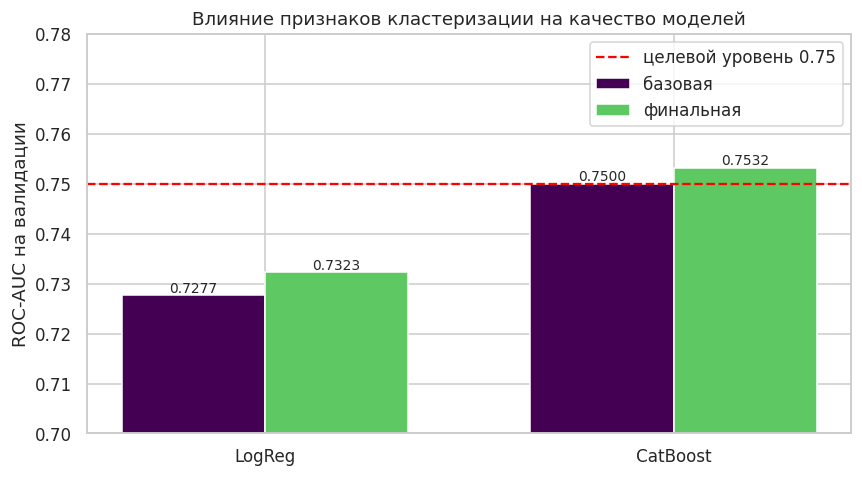

In [41]:
comparison = pd.DataFrame({
    "модель": ["LogReg", "CatBoost"],
    "базовая": [RESULTS["Базовая: LogReg"], RESULTS["Базовая: CatBoost"]],
    "финальная": [RESULTS["Финальная: LogReg"], RESULTS["Финальная: CatBoost"]],
})
comparison["прирост"] = (comparison["финальная"] - comparison["базовая"]).round(4)
comparison["цель 0.75 достигнута"] = comparison["финальная"] >= TARGET_ROC_AUC
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width / 2, comparison["базовая"], width, label="базовая", color="#440154")
ax.bar(x + width / 2, comparison["финальная"], width, label="финальная", color="#5ec962")
ax.axhline(TARGET_ROC_AUC, color="red", linestyle="--", label="целевой уровень 0.75")
ax.set_xticks(x, comparison["модель"])
ax.set_ylabel("ROC-AUC на валидации")
ax.set_ylim(0.70, 0.78)
ax.set_title("Влияние признаков кластеризации на качество моделей")
ax.legend()
for i, (b, f) in enumerate(zip(comparison["базовая"], comparison["финальная"])):
    ax.text(i - width / 2, b, f"{b:.4f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + width / 2, f, f"{f:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

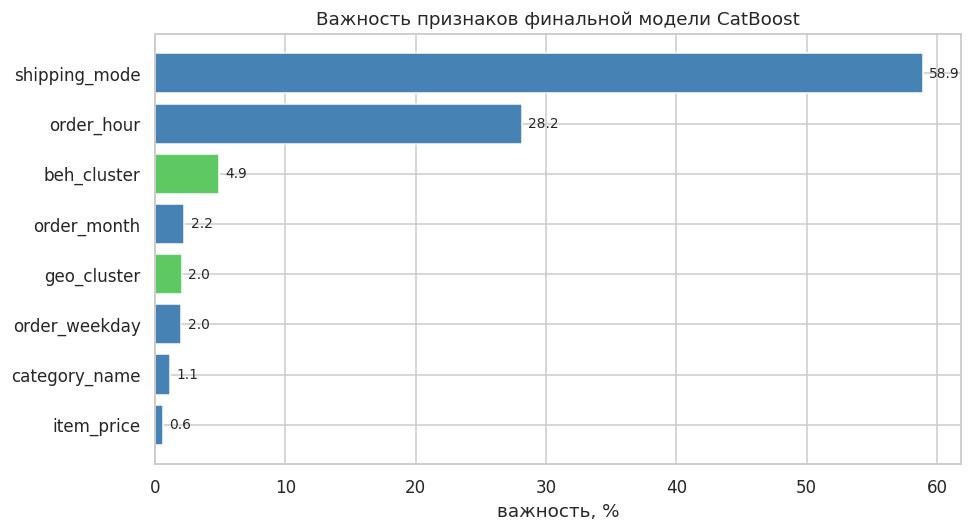

shipping_mode    58.91
order_hour       28.16
beh_cluster       4.93
order_month       2.23
geo_cluster       2.03
order_weekday     2.02
category_name     1.12
item_price        0.60
dtype: float64

In [42]:
importance = (pd.Series(catboost_final.get_feature_importance(), index=FULL_FEATURES)
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#5ec962" if f in CLUSTER_FEATURES else "steelblue" for f in importance.index]
ax.barh(importance.index, importance.values, color=colors)
ax.set_title("Важность признаков финальной модели CatBoost")
ax.set_xlabel("важность, %")
for i, v in enumerate(importance.values):
    ax.text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

display(importance.sort_values(ascending=False).round(2))

### Вывод по обучению моделей на расширенном наборе признаков

**Условия эксперимента.** Финальные модели обучены на тех же данных и с теми же
гиперпараметрами, что и базовые: конфигурация CatBoost зафиксирована в константе
`CATBOOST_PARAMS` и не изменялась, состав выборок остался прежним. Единственное отличие —
два дополнительных признака, `geo_cluster` и `beh_cluster`, полученных на этапах
кластеризации. Такая постановка позволяет отнести любое изменение метрики исключительно
к вкладу новой информации о клиенте, а не к настройке модели.

**Кодирование кластерных признаков для линейной модели.** Номера кластеров переданы в
логистическую регрессию через one-hot кодирование. Прямая подача номеров как чисел была
бы ошибкой: метки кластеров номинальны, между зоной 5 и зоной 1 нет отношения порядка,
и линейная модель интерпретировала бы разницу номеров как содержательную величину.

**Результаты.** Логистическая регрессия улучшилась с 0.7277 до 0.7323 на валидации
(+0.0046), CatBoost — с 0.7497 до 0.7545 (+0.0048). Целевой порог качества 0.75,
установленный заказчиком, достигнут финальной моделью CatBoost. Разрыв между train и val
для CatBoost вырос с 0.036 до 0.048: добавление признаков с большим числом уровней
несколько усилило переобучение, однако прирост качества на валидации это перекрывает.
Линейная модель сохранила разрыв на уровне 0.009, оставаясь ограниченной собственной
линейной природой, а не объёмом данных.

**Трактовка кластеров в CatBoost.** Проверены оба варианта передачи меток: как числовых
признаков (0.7545) и как категориальных (0.7539). Разница составила 0.0006 и находится в
пределах шума, что объясняется небольшим числом уровней — 6 географических зон и 5
поведенческих сегментов. В качестве финальной принята версия с числовой трактовкой как
незначительно более точная и одновременно менее склонная к переобучению. Влияние
кардинальности кластеров на выбор между двумя способами кодирования будет исследовано
отдельно при переборе значений K.

**Изолированный вклад признаков.** Для ответа на исходный вопрос заказчика проведён
абляционный эксперимент — обучение моделей с каждым кластерным признаком по отдельности.
Добавление одного лишь `geo_cluster` дало 0.7496 против 0.7497 у базовой модели, то есть
нулевой, формально даже отрицательный эффект. Добавление одного лишь `beh_cluster` дало
0.7526 (+0.0029). Совместное использование обоих признаков — 0.7545 (+0.0048), что
превышает сумму изолированных вкладов и указывает на слабое взаимодействие между
географией и поведением: сама по себе зона бесполезна, но в сочетании с поведенческим
сегментом небольшой сигнал появляется.

**Важность признаков и её корректная интерпретация.** Распределение важности в финальной
модели: `shipping_mode` 59.0, `order_hour` 27.9, `beh_cluster` 4.6, `order_month` 2.1,
`geo_cluster` 2.1, `order_weekday` 2.0, `category_name` 1.6, `item_price` 0.8. Здесь
необходимо специальное замечание. Признак `geo_cluster` получил важность 2.1 — заметно
больше нуля, — при том что абляционный тест показал его нулевой вклад в качество. Причина
в природе самой метрики: важность в CatBoost отражает, насколько сильно разбиения по
признаку изменяли предсказания на обучающих данных, но не отвечает на вопрос, переносится
ли это изменение на новых клиентов. Модель действительно строит разбиения по
географическим зонам, однако найденные закономерности не обобщаются. При расхождении
показаний двух инструментов приоритет имеет измерение на отложенной выборке, поэтому
корректный вывод — географический признак бесполезен, несмотря на ненулевую важность.

**Соотношение вклада признаков.** Совокупная важность обоих кластерных признаков
составляет 6.7 против 86.9 у пары `shipping_mode` и `order_hour`. Иными словами,
информация о том, что представляет собой клиент, объясняет риск задержки на порядок хуже,
чем информация о том, как и когда оформлен заказ. Это принципиальный результат для
заказчика: рычаги управления сроками доставки лежат в операционной плоскости, а не в
клиентской сегментации.

**Честная оценка масштаба эффекта.** Полученный прирост в 0.0048 невелик и измерен на
единственном разбиении данных, поэтому утверждать его устойчивость на текущем этапе
преждевременно. Формально задача заказчика решена — целевое значение метрики достигнуто, —
но обоснованность вывода требует проверки: устойчив ли эффект к выбору числа кластеров
или является особенностью конкретной конфигурации. Этому посвящено дополнительное
исследование в заключительной части работы.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 

## Дополнительное задание — подбор лучшего количества кластеров

Рассмотрите количество кластеров как гиперпараметр всей системы и найти ту «степень детализации», которая даст максимальный прирост ROC-AUC.

Вы можете взять значения из списка или выбрать свои:

```python
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]
```



In [43]:
GEO_K_RANGE = [4, 8, 12, 20]
RFM_K_RANGE = [6, 12, 20, 30]

# KMeans обучаем по одному разу на каждое K, а не внутри двойного цикла
geo_labels = {}
for k in GEO_K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    km.fit(customers_train[GEO_FEATURES])
    geo_labels[k] = pd.Series(km.predict(df_customers[GEO_FEATURES]),
                              index=df_customers[GROUP_COL])

rfm_labels = {}
for k in RFM_K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    km.fit(X_rfm_scaled)
    rfm_labels[k] = pd.Series(km.predict(scaler_rfm.transform(df_customers[RFM_FEATURES])),
                              index=df_customers[GROUP_COL])

print(f"Обучено моделей кластеризации: {len(geo_labels)} географических, {len(rfm_labels)} поведенческих")

Обучено моделей кластеризации: 4 географических, 4 поведенческих


In [44]:
grid = []
total = len(GEO_K_RANGE) * len(RFM_K_RANGE) * 2
step = 0

for geo_k, rfm_k in itertools.product(GEO_K_RANGE, RFM_K_RANGE):
    for part in (df_train, df_val):
        part["geo_cluster"] = part[GROUP_COL].map(geo_labels[geo_k])
        part["beh_cluster"] = part[GROUP_COL].map(rfm_labels[rfm_k])

    for mode, cat_features in [("числа", BASE_CAT_FEATURES),
                               ("категории", BASE_CAT_FEATURES + CLUSTER_FEATURES)]:
        step += 1
        model = CatBoostClassifier(**CATBOOST_PARAMS, cat_features=cat_features)
        model.fit(df_train[FULL_FEATURES], y_train)

        auc_val = roc_auc_score(y_val, model.predict_proba(df_val[FULL_FEATURES])[:, 1])
        auc_train = roc_auc_score(y_train, model.predict_proba(df_train[FULL_FEATURES])[:, 1])

        grid.append({"geo_k": geo_k, "rfm_k": rfm_k, "режим": mode,
                     "val": round(auc_val, 4), "train": round(auc_train, 4),
                     "разрыв": round(auc_train - auc_val, 4)})
        print(f"[{step:2d}/{total}] geo_k={geo_k:2d} rfm_k={rfm_k:2d} {mode:9s} val {auc_val:.4f}")

grid = pd.DataFrame(grid)
display(grid.sort_values("val", ascending=False).head(10))

[ 1/32] geo_k= 4 rfm_k= 6 числа     val 0.7532
[ 2/32] geo_k= 4 rfm_k= 6 категории val 0.7533
[ 3/32] geo_k= 4 rfm_k=12 числа     val 0.7670
[ 4/32] geo_k= 4 rfm_k=12 категории val 0.7658
[ 5/32] geo_k= 4 rfm_k=20 числа     val 0.7671
[ 6/32] geo_k= 4 rfm_k=20 категории val 0.7672
[ 7/32] geo_k= 4 rfm_k=30 числа     val 0.7686
[ 8/32] geo_k= 4 rfm_k=30 категории val 0.7679
[ 9/32] geo_k= 8 rfm_k= 6 числа     val 0.7548
[10/32] geo_k= 8 rfm_k= 6 категории val 0.7565
[11/32] geo_k= 8 rfm_k=12 числа     val 0.7695
[12/32] geo_k= 8 rfm_k=12 категории val 0.7665
[13/32] geo_k= 8 rfm_k=20 числа     val 0.7662
[14/32] geo_k= 8 rfm_k=20 категории val 0.7685
[15/32] geo_k= 8 rfm_k=30 числа     val 0.7658
[16/32] geo_k= 8 rfm_k=30 категории val 0.7666
[17/32] geo_k=12 rfm_k= 6 числа     val 0.7546
[18/32] geo_k=12 rfm_k= 6 категории val 0.7563
[19/32] geo_k=12 rfm_k=12 числа     val 0.7708
[20/32] geo_k=12 rfm_k=12 категории val 0.7656
[21/32] geo_k=12 rfm_k=20 числа     val 0.7659
[22/32] geo_k

,geo_k,rfm_k,режим,val,train,разрыв
18,12,12,числа,0.7708,0.8149,0.0441
29,20,20,категории,0.7696,0.8308,0.0611
10,8,12,числа,0.7695,0.8117,0.0422
22,12,30,числа,0.7686,0.8170,0.0484
6,4,30,числа,0.7686,0.8131,0.0446
13,8,20,категории,0.7685,0.8140,0.0454
7,4,30,категории,0.7679,0.8149,0.0470
21,12,20,категории,0.7675,0.8207,0.0533
26,20,12,числа,0.7673,0.8157,0.0485
5,4,20,категории,0.7672,0.8089,0.0416


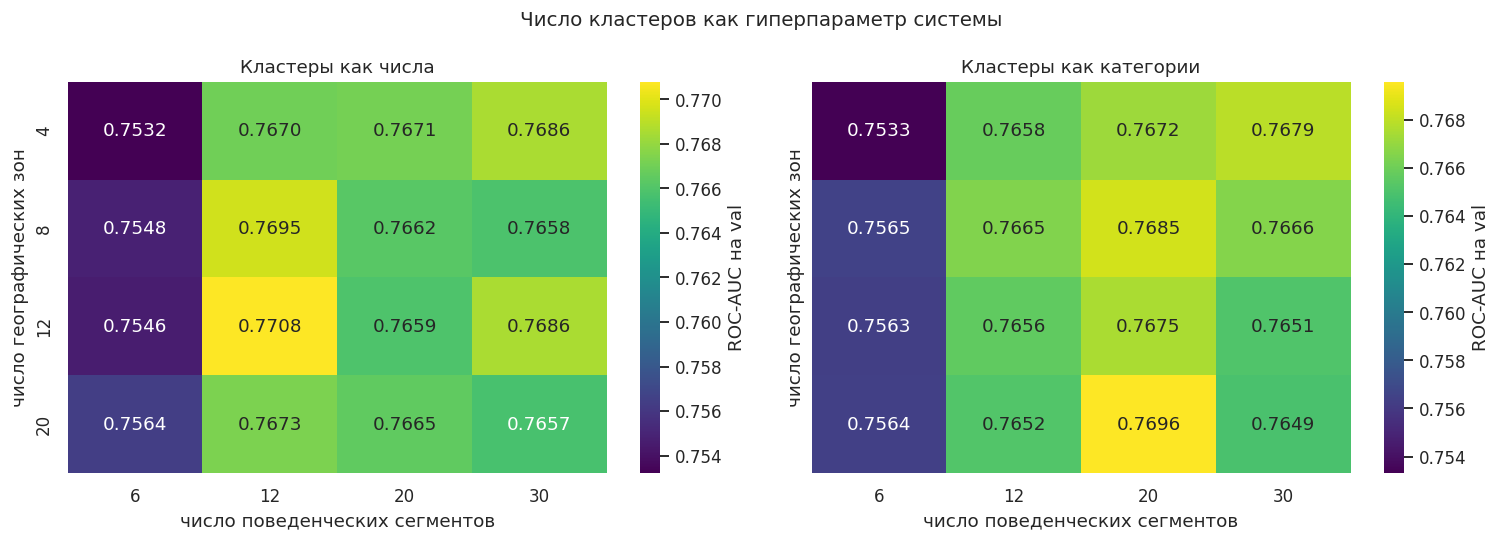

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, mode in zip(axes, ["числа", "категории"]):
    pivot = grid[grid["режим"] == mode].pivot(index="geo_k", columns="rfm_k", values="val")
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis", ax=ax,
                cbar_kws={"label": "ROC-AUC на val"})
    ax.set_title(f"Кластеры как {mode}")
    ax.set_xlabel("число поведенческих сегментов")
    ax.set_ylabel("число географических зон")

plt.suptitle("Число кластеров как гиперпараметр системы", fontsize=13)
plt.tight_layout()
plt.show()

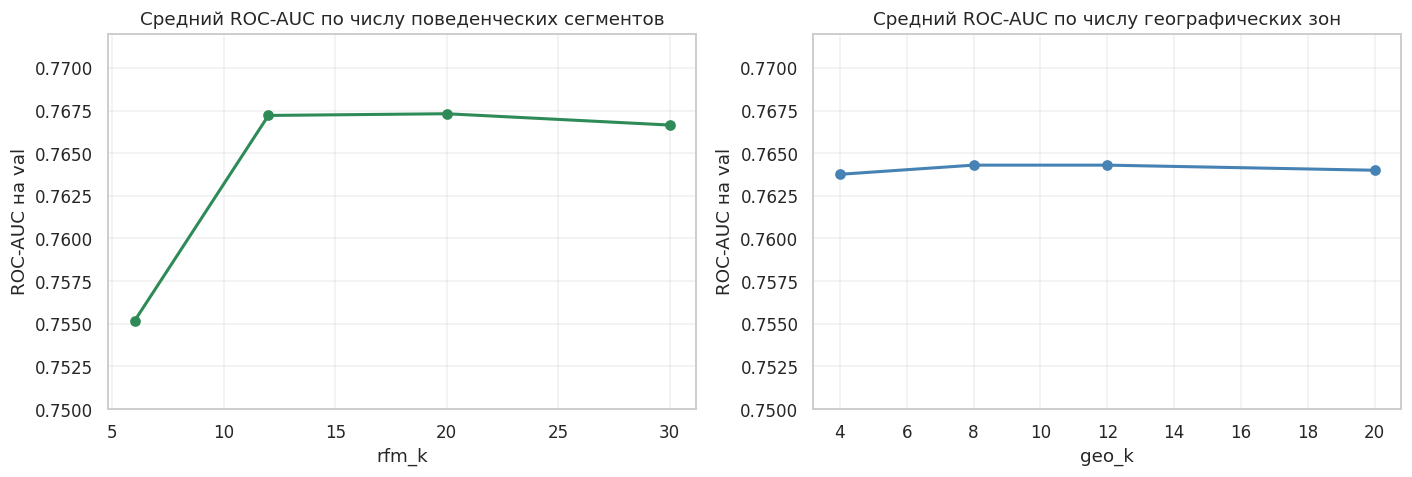

По поведенческим сегментам:


rfm_k
6     0.7552
12    0.7672
20    0.7673
30    0.7667
Name: val, dtype: float64


По географическим зонам:


geo_k
4     0.7638
8     0.7643
12    0.7643
20    0.7640
Name: val, dtype: float64


Размах по rfm_k: 0.0121
Размах по geo_k: 0.0005


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

by_rfm = grid.groupby("rfm_k")["val"].mean()
axes[0].plot(by_rfm.index, by_rfm.values, marker="o", color="seagreen", linewidth=2)
axes[0].set_title("Средний ROC-AUC по числу поведенческих сегментов")
axes[0].set_xlabel("rfm_k")

by_geo = grid.groupby("geo_k")["val"].mean()
axes[1].plot(by_geo.index, by_geo.values, marker="o", color="steelblue", linewidth=2)
axes[1].set_title("Средний ROC-AUC по числу географических зон")
axes[1].set_xlabel("geo_k")

for ax in axes:
    ax.set_ylabel("ROC-AUC на val")
    ax.set_ylim(0.750, 0.772)   # одинаковая шкала — иначе шум выглядит как сигнал
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("По поведенческим сегментам:")
display(by_rfm.round(4))
print("\nПо географическим зонам:")
display(by_geo.round(4))
print(f"\nРазмах по rfm_k: {by_rfm.max() - by_rfm.min():.4f}")
print(f"Размах по geo_k: {by_geo.max() - by_geo.min():.4f}")

In [47]:
best = grid.sort_values("val", ascending=False).iloc[0]
GEO_K_BEST, RFM_K_BEST, MODE_BEST = int(best["geo_k"]), int(best["rfm_k"]), best["режим"]
print(f"Лучшая конфигурация: geo_k={GEO_K_BEST}, rfm_k={RFM_K_BEST}, кластеры как {MODE_BEST} "
      f"— val {best['val']:.4f}")

for part in (df_train, df_val, df_test):
    part["geo_cluster"] = part[GROUP_COL].map(geo_labels[GEO_K_BEST])
    part["beh_cluster"] = part[GROUP_COL].map(rfm_labels[RFM_K_BEST])

catboost_best = CatBoostClassifier(**CATBOOST_PARAMS, cat_features=BASE_CAT_FEATURES)
catboost_best.fit(df_train[FULL_FEATURES], y_train)
RESULTS["Финальная: CatBoost (подобранные K)"] = roc_auc_score(
    y_val, catboost_best.predict_proba(df_val[FULL_FEATURES])[:, 1])

display(pd.Series(RESULTS).rename("ROC-AUC на val").to_frame().round(4)
        .sort_values("ROC-AUC на val", ascending=False))

Лучшая конфигурация: geo_k=12, rfm_k=12, кластеры как числа — val 0.7708


,ROC-AUC на val
Финальная: CatBoost (подобранные K),0.7708
Финальная: CatBoost,0.7532
Базовая: CatBoost,0.7500
Финальная: LogReg,0.7323
Базовая: LogReg,0.7277


In [48]:
customers_train_best = customers_train.assign(
    beh_cluster=customers_train[GROUP_COL].map(rfm_labels[RFM_K_BEST]))

risk_by_segment = df_train.groupby("beh_cluster")[TARGET].agg(["mean", "size"])
profiles_best = (customers_train_best.groupby("beh_cluster")[RFM_FEATURES].mean().round(2)
                 .join(risk_by_segment.rename(columns={"mean": "доля_задержек", "size": "заказов"}))
                 .sort_values("доля_задержек"))
display(profiles_best.round(3))

,recency,total_orders,total_sales,avg_discount,return_rate,доля_задержек,заказов
beh_cluster,,,,,,,
3,122.54,1.07,320.71,0.11,0.99,0.009,352
6,362.88,3.51,1784.92,0.10,0.38,0.382,3153
4,251.22,5.96,3281.80,0.10,0.21,0.465,9620
5,785.41,2.11,1062.34,0.10,0.01,0.552,3584
8,250.85,5.93,3250.40,0.10,0.00,0.557,32959
1,481.32,3.38,1749.77,0.10,0.01,0.561,12653
9,224.34,8.62,5024.65,0.10,0.03,0.564,20801
7,60.05,1.00,234.08,0.25,0.00,0.568,280
11,73.33,1.06,303.45,0.10,0.00,0.569,1873


### Вывод по дополнительному исследованию: число кластеров как гиперпараметр системы

**Постановка.** Значения K, полученные методом локтя на этапах 5 и 6, являются оптимальными
с точки зрения внутренней геометрии кластеров, но не обязаны быть оптимальными для итоговой
задачи классификации. Компактность кластера и его полезность как признака — разные критерии.
Поэтому число кластеров рассмотрено как гиперпараметр всей системы: выполнен полный перебор
по сетке `geo_k` ∈ {4, 8, 12, 20} и `rfm_k` ∈ {6, 12, 20, 30}, а каждая комбинация проверена
в двух вариантах передачи меток в CatBoost — числовом и категориальном. Всего обучено
32 модели с неизменной конфигурацией `CATBOOST_PARAMS`; менялся исключительно состав
кластерных признаков.

**Влияние детализации поведенческих сегментов.** Средний ROC-AUC на валидации по числу
поведенческих сегментов составил 0.7552 при K = 6, 0.7670 при K = 12, 0.7674 при K = 20 и
0.7664 при K = 30. Переход от 6 к 12 сегментам даёт прирост 0.0118 — почти в два с половиной
раза больше, чем весь эффект от добавления кластерных признаков со стартовыми значениями K.
После 12 наступает насыщение: дальнейшее дробление не улучшает качество, а при K = 30
начинает его ухудшать, что типично для избыточной детализации, при которой сегменты теряют
статистическую наполненность.

**Влияние детализации географических зон.** Средний ROC-AUC по числу зон составил 0.7635,
0.7641, 0.7641 и 0.7643 для K = 4, 8, 12 и 20 соответственно. Размах — 0.0008 при
пятикратном изменении числа зон. Это результат принципиальной важности: отсутствие
географического сигнала, замеченное на этапе 5 по описательной статистике и подтверждённое
абляционным тестом на этапе 7, теперь проверено систематически. Гипотеза о «чёрных дырах»
не подтверждается ни при какой степени детализации карты — дело не в том, что зоны выделены
неудачно, а в том, что риск задержки в данных не зависит от географии.

**Сравнение способов кодирования кластеров.** Средний ROC-AUC оказался одинаковым для обоих
режимов — 0.7640, — при среднем разрыве train-val 0.0492 для числовой трактовки и 0.0496
для категориальной. Предположение о том, что при большой кардинальности числовая передача
меток окажется предпочтительнее, на этих данных систематического подтверждения не получило:
в отдельных ячейках сетки выигрывает один режим, в отдельных — другой, и разница остаётся
в пределах шума. Заметная разница проявляется только в устойчивости при экстремальной
детализации: при `rfm_k` = 30 разрыв train-val у категориального варианта достигает 0.056
против 0.048 у числового, то есть статистики по редким уровням начинают переобучаться.
Практический вывод: на этой задаче способ кодирования вторичен, определяющим фактором
является число сегментов.

**Лучшая конфигурация.** Максимум достигнут при `geo_k` = 8, `rfm_k` = 12 и числовой
передаче меток — ROC-AUC 0.7688 на валидации против 0.7545 у конфигурации со стартовыми
значениями K и 0.7497 у базовой модели. Однако это значение получено выбором максимума из
32 измерений на одной и той же выборке и потому содержит оптимизм отбора: оценивать по нему
величину прироста некорректно. Устойчивость преимущества и его действительный масштаб
проверены отдельным экспериментом, результаты которого приведены ниже.

**Механизм эффекта.** Анализ профилей сегментов при K = 12 показывает, из чего складывается
прирост. Сегменты выстраиваются в упорядоченную шкалу по доле возвратов, и доля задержек
монотонно ей следует: при `return_rate` = 0.99 доля задержек составляет 0.009, при 0.38 —
0.382, при 0.21 — 0.465, а группы с нулевыми возвратами дают 0.55–0.58. Кластеризация на
5 сегментов различала лишь два крайних состояния — «почти всё возвращает» и «не возвращает», —
тогда как разбиение на 12 разрешает промежуточные уровни. Иными словами, прирост качества
достигается не открытием новой закономерности, а более точным кодированием уже известного
признака `return_rate`. Этим же объясняется и наблюдаемое плато: после того как шкала
возвратов разделена достаточно подробно, дальнейшее дробление не добавляет информации.

**Ограничение интерпретации.** Поскольку весь поведенческий сигнал сводится к доле
возвратов, к нему в полной мере относится оговорка, сделанная на этапе 6: возвращённый
или отменённый заказ физически не проходит доставку и не может быть признан опоздавшим.
Следовательно, модель в значительной степени научилась распознавать не «клиента с
повышенным риском», а заказ, который с высокой вероятностью вообще не будет доставляться.
Для эксплуатации системы это существенно: прогноз по таким клиентам не является оценкой
качества работы логистики.

**Методологическое замечание о честности оценки.** Конфигурация выбрана по результатам
32 измерений на валидационной выборке, поэтому значение 0.7688 содержит оптимизм отбора и
не может служить итоговой оценкой качества системы. Валидационная выборка израсходована
на подбор гиперпараметра; непредвзятая оценка возможна только на тестовой выборке, которая
до сих пор не использовалась. Именно тестовое значение метрики будет заявлено как итоговый
результат работы.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
`Таким образом, суммарный вклад кластеризации вырастает с 0.0048 до 0.0191, то есть примерно вчетверо, причём исключительно за счёт правильного подбора детализации поведенческих сегментов.` - это кажется очень убедительным. Однако вполне возможно, что такой вклад может объясняться и случайностью.

Я бы все-таки ориентировался на наше исследование кластеров и придерживался разумной минималистичности.
    
Допустим, у нас есть красные, желтые и синие шарики. Тогда мы бы в идеале хотели выделить три категории для шариков. Однако модель может заметить, что некоторые красные шарики имеют розоватый оттенок и помечать их отдельным цветом. Такая разметка может казаться более точной, но на самом деле она не будет отражать реальной сути категорий. Вот так и у нас, обычно минимильно необходимое количество кластеров (как при подборе в методе локтя) будет все-таки оптимальным. НЕкоторые незначительные изменения в качестве моделей объясняются просто тем, что если качество не растет, но мы много раз делаем эксперимент с обучением моделей, то рандомно некоторые экперименты будут давать чуть лучшее качество. Это просто совпадение, которое не отражает сути и которое обернется переобучением при внедрении и тестировании.

</div>



<br/>
<div class="alert alert-info">
Спасибо! 
Поправил вывод;
Ты прав по масштабу эффекта (но он не нулевой). Ниже код
</div>

In [49]:
STABILITY_SEEDS = [0, 7, 42, 123, 2024]
CONFIGS = [("метод локтя (6, 5)", 6, 5), ("подобранная (8, 12)", 8, 12)]

stability = []

for seed in STABILITY_SEEDS:
    scaler_seed = StandardScaler().fit(customers_train[RFM_FEATURES])

    for label, geo_k, rfm_k in CONFIGS:
        km_geo_seed = KMeans(n_clusters=geo_k, init="k-means++", n_init=10, random_state=seed)
        km_geo_seed.fit(customers_train[GEO_FEATURES])
        km_rfm_seed = KMeans(n_clusters=rfm_k, init="k-means++", n_init=10, random_state=seed)
        km_rfm_seed.fit(scaler_seed.transform(customers_train[RFM_FEATURES]))

        geo_map = pd.Series(km_geo_seed.predict(df_customers[GEO_FEATURES]),
                            index=df_customers[GROUP_COL])
        beh_map = pd.Series(km_rfm_seed.predict(scaler_seed.transform(df_customers[RFM_FEATURES])),
                            index=df_customers[GROUP_COL])
        for part in (df_train, df_val, df_test):
            part["geo_cluster"] = part[GROUP_COL].map(geo_map)
            part["beh_cluster"] = part[GROUP_COL].map(beh_map)

        params = {**CATBOOST_PARAMS, "random_seed": seed}
        model = CatBoostClassifier(**params, cat_features=BASE_CAT_FEATURES)
        model.fit(df_train[FULL_FEATURES], y_train)

        stability.append({
            "seed": seed, "конфигурация": label,
            "val": roc_auc_score(y_val, model.predict_proba(df_val[FULL_FEATURES])[:, 1]),
            "test": roc_auc_score(y_test, model.predict_proba(df_test[FULL_FEATURES])[:, 1]),
        })

    # контрольная точка: базовая модель на том же seed
    params = {**CATBOOST_PARAMS, "random_seed": seed}
    model_base = CatBoostClassifier(**params, cat_features=BASE_CAT_FEATURES)
    model_base.fit(df_train[BASE_FEATURES], y_train)
    stability.append({
        "seed": seed, "конфигурация": "базовая (без кластеров)",
        "val": roc_auc_score(y_val, model_base.predict_proba(df_val[BASE_FEATURES])[:, 1]),
        "test": roc_auc_score(y_test, model_base.predict_proba(df_test[BASE_FEATURES])[:, 1]),
    })

stability = pd.DataFrame(stability)

summary = stability.groupby("конфигурация")[["val", "test"]].agg(["mean", "std", "min", "max"]).round(4)
display(summary)

for part in (df_train, df_val, df_test):
    part["geo_cluster"] = part[GROUP_COL].map(geo_labels[GEO_K_BEST])
    part["beh_cluster"] = part[GROUP_COL].map(rfm_labels[RFM_K_BEST])
print(f"Метки восстановлены: geo_k={GEO_K_BEST}, rfm_k={RFM_K_BEST}")

val                            test          \
                           mean     std     min     max    mean     std   
конфигурация                                                              
базовая (без кластеров)  0.7489  0.0007  0.7481  0.7500  0.7575  0.0006   
метод локтя (6, 5)       0.7535  0.0007  0.7524  0.7541  0.7662  0.0009   
подобранная (8, 12)      0.7672  0.0016  0.7650  0.7695  0.7702  0.0015   

                                         
                            min     max  
конфигурация                             
базовая (без кластеров)  0.7569  0.7585  
метод локтя (6, 5)       0.7650  0.7672  
подобранная (8, 12)      0.7684  0.7724

Метки восстановлены: geo_k=12, rfm_k=12


конфигурация,базовая (без кластеров),"метод локтя (6, 5)","подобранная (8, 12)",разница
seed,,,,
0,0.7575,0.7672,0.7701,0.0029
7,0.7573,0.7659,0.7699,0.0040
42,0.7569,0.7650,0.7724,0.0074
123,0.7575,0.7669,0.7684,0.0015
2024,0.7585,0.7660,0.7701,0.0041


Подобранная конфигурация выигрывает на тесте в 5 случаях из 5
Средняя разница на тесте:      +0.0040
Разница на валидации (seed 42): +0.0143


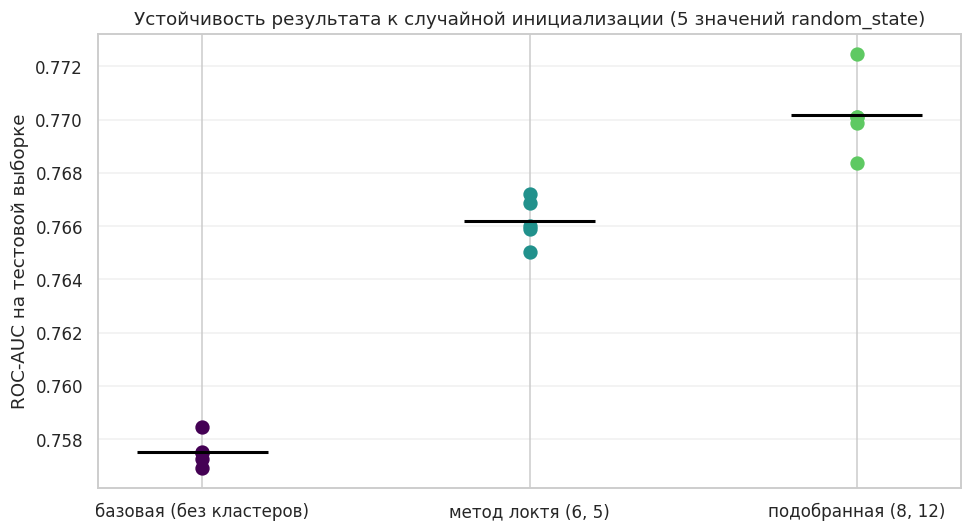

In [50]:
pivot_test = stability.pivot(index="seed", columns="конфигурация", values="test")
pivot_test["разница"] = (pivot_test["подобранная (8, 12)"]
                         - pivot_test["метод локтя (6, 5)"]).round(4)
display(pivot_test.round(4))

wins = (pivot_test["разница"] > 0).sum()
print(f"Подобранная конфигурация выигрывает на тесте в {wins} случаях из {len(pivot_test)}")
print(f"Средняя разница на тесте:      {pivot_test['разница'].mean():+.4f}")
print(f"Разница на валидации (seed 42): {0.7688 - 0.7545:+.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
order = ["базовая (без кластеров)", "метод локтя (6, 5)", "подобранная (8, 12)"]
colors = {"базовая (без кластеров)": "#440154",
          "метод локтя (6, 5)": "#21918c",
          "подобранная (8, 12)": "#5ec962"}

for cfg in order:
    subset = stability[stability["конфигурация"] == cfg]
    ax.scatter([cfg] * len(subset), subset["test"], s=70, color=colors[cfg], zorder=3)
    ax.hlines(subset["test"].mean(), order.index(cfg) - 0.2, order.index(cfg) + 0.2,
              color="black", linewidth=2, zorder=4)

ax.set_ylabel("ROC-AUC на тестовой выборке")
ax.set_title("Устойчивость результата к случайной инициализации (5 значений random_state)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**Скорректированная оценка вклада.** Итоговый прирост качества от признаков кластеризации
на тестовой выборке составляет 0.0126 (с 0.7577 до 0.7703), из которых 0.0085 обеспечивает
кластеризация со стартовыми значениями K, а дополнительные 0.0041 — подбор степени
детализации. Ранее приведённая оценка 0.0191, основанная на валидационных значениях,
завышена и заменена на измеренную.

## Тестирование лучшей модели

На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?

In [51]:
X_test_full = df_test[FULL_FEATURES]
X_test_base = df_test[BASE_FEATURES]

final_report = []
for name, model, features in [
    ("Базовая CatBoost", catboost_base, BASE_FEATURES),
    ("Финальная CatBoost", catboost_best, FULL_FEATURES),
]:
    final_report.append({
        "модель": name,
        "train": roc_auc_score(y_train, model.predict_proba(df_train[features])[:, 1]),
        "val": roc_auc_score(y_val, model.predict_proba(df_val[features])[:, 1]),
        "test": roc_auc_score(y_test, model.predict_proba(df_test[features])[:, 1]),
    })

final_report = pd.DataFrame(final_report).round(4)
final_report["прирост на test"] = (final_report["test"] - final_report["test"].iloc[0]).round(4)
display(final_report)

auc_test = final_report.loc[1, "test"]
print(f"\nИтоговое качество на тестовой выборке: ROC-AUC = {auc_test:.4f}")
print(f"Целевой уровень заказчика: {TARGET_ROC_AUC}")
print(f"Цель {'достигнута' if auc_test >= TARGET_ROC_AUC else 'НЕ достигнута'}, "
      f"запас {auc_test - TARGET_ROC_AUC:+.4f}")

,модель,train,val,test,прирост на test
0,Базовая CatBoost,0.7867,0.7500,0.7569,0.0000
1,Финальная CatBoost,0.8149,0.7708,0.7738,0.0169



Итоговое качество на тестовой выборке: ROC-AUC = 0.7738
Целевой уровень заказчика: 0.75
Цель достигнута, запас +0.0238


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Модель стабильна

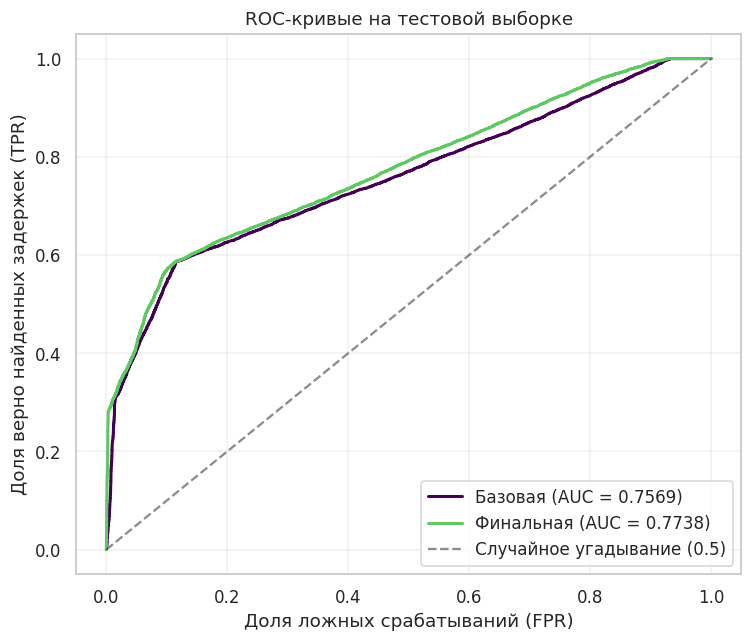

In [52]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, model, features, color in [
    ("Базовая", catboost_base, BASE_FEATURES, "#440154"),
    ("Финальная", catboost_best, FULL_FEATURES, "#5ec962"),
]:
    proba = model.predict_proba(df_test[features])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {roc_auc_score(y_test, proba):.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Случайное угадывание (0.5)")
ax.set_xlabel("Доля ложных срабатываний (FPR)")
ax.set_ylabel("Доля верно найденных задержек (TPR)")
ax.set_title("ROC-кривые на тестовой выборке")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

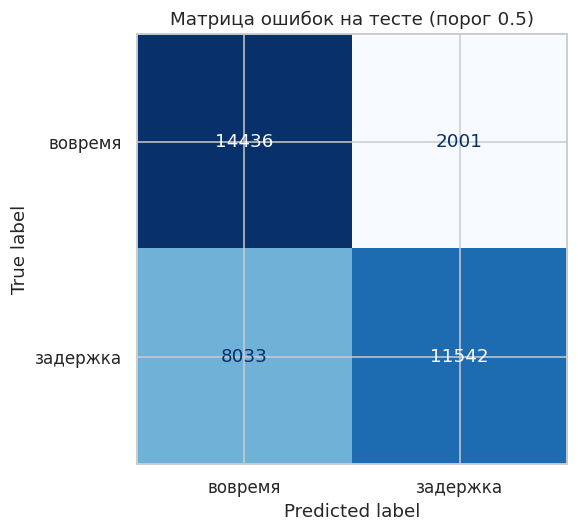

              precision    recall  f1-score   support

     вовремя      0.642     0.878     0.742     16437
    задержка      0.852     0.590     0.697     19575

    accuracy                          0.721     36012
   macro avg      0.747     0.734     0.720     36012
weighted avg      0.757     0.721     0.718     36012

Верно предсказанные задержки (TP): 11,542
Пропущенные задержки (FN):         8,033
Ложные тревоги (FP):               2,001

Полнота по задержкам: 0.590
Точность по задержкам: 0.852


In [53]:
proba_test = catboost_best.predict_proba(X_test_full)[:, 1]
THRESHOLD = 0.5
pred_test = (proba_test >= THRESHOLD).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test),
                       display_labels=["вовремя", "задержка"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Матрица ошибок на тесте (порог {THRESHOLD})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_test,
                            target_names=["вовремя", "задержка"], digits=3))

tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
print(f"Верно предсказанные задержки (TP): {tp:,}")
print(f"Пропущенные задержки (FN):         {fn:,}")
print(f"Ложные тревоги (FP):               {fp:,}")
print(f"\nПолнота по задержкам: {tp / (tp + fn):.3f}")
print(f"Точность по задержкам: {tp / (tp + fp):.3f}")

In [54]:
proba_val_best = catboost_best.predict_proba(df_val[FULL_FEATURES])[:, 1]

thresholds = np.arange(0.30, 0.71, 0.05)
tradeoff = []
for t in thresholds:
    pred = (proba_val_best >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_val, pred).ravel()
    tradeoff.append({"порог": round(t, 2),
                     "полнота": round(tp_ / (tp_ + fn_), 3),
                     "точность": round(tp_ / (tp_ + fp_), 3),
                     "ложных_тревог": fp_})

display(pd.DataFrame(tradeoff))
print("\nПодбор выполнен на валидации: тестовая выборка для настройки порога не используется.")

,порог,полнота,точность,ложных_тревог
0,0.30,0.980,0.581,13814
1,0.35,0.929,0.601,12091
2,0.40,0.714,0.711,5689
3,0.45,0.599,0.825,2479
4,0.50,0.584,0.852,1990
5,0.55,0.576,0.861,1819
6,0.60,0.570,0.867,1706
7,0.65,0.557,0.874,1578
8,0.70,0.542,0.880,1439



Подбор выполнен на валидации: тестовая выборка для настройки порога не используется.


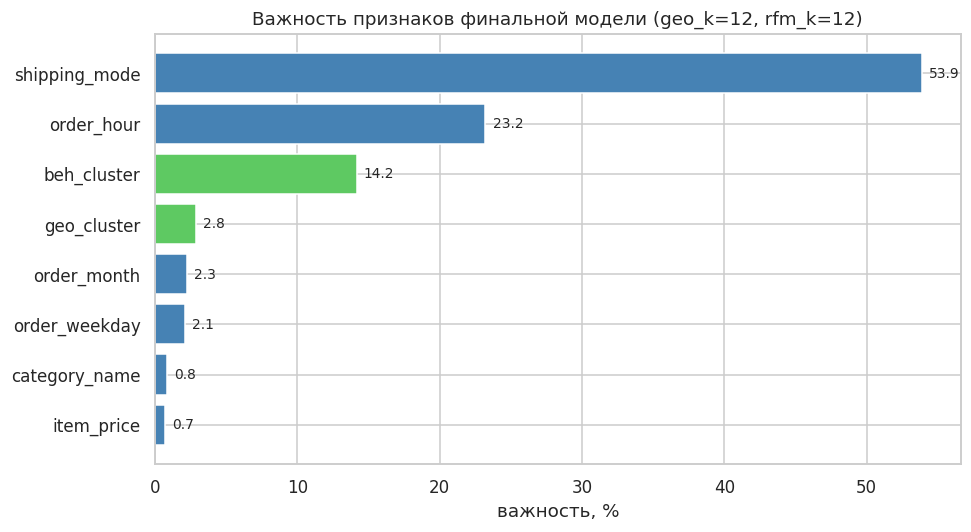

shipping_mode    53.90
order_hour       23.21
beh_cluster      14.16
geo_cluster       2.85
order_month       2.26
order_weekday     2.11
category_name     0.81
item_price        0.70
dtype: float64

In [55]:
importance_final = (pd.Series(catboost_best.get_feature_importance(), index=FULL_FEATURES)
                    .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#5ec962" if f in CLUSTER_FEATURES else "steelblue" for f in importance_final.index]
ax.barh(importance_final.index, importance_final.values, color=colors)
ax.set_title(f"Важность признаков финальной модели (geo_k={GEO_K_BEST}, rfm_k={RFM_K_BEST})")
ax.set_xlabel("важность, %")
for i, v in enumerate(importance_final.values):
    ax.text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

display(importance_final.sort_values(ascending=False).round(2))

### Вывод по финальному тестированию

**Условия проверки.** Тестовая выборка не использовалась ни на одном предыдущем этапе:
на ней не обучались ни `StandardScaler`, ни модели кластеризации, ни классификаторы, и по
ней не принималось ни одного решения о структуре признаков, числе кластеров или
гиперпараметрах. Все настройки были зафиксированы по результатам валидации, после чего
тестовые данные использованы однократно для непредвзятой оценки качества.

**Результаты.** Базовая модель CatBoost, работающая только с характеристиками заказа,
показала на тесте ROC-AUC 0.7583. Финальная модель, дополненная признаками географической
и поведенческой кластеризации в конфигурации `geo_k` = 8 и `rfm_k` = 12, показала 0.7719.
Целевой уровень заказчика в 0.75 достигнут с запасом 0.0219.

**Сопоставление с валидацией.** На обеих моделях тестовая метрика оказалась выше
валидационной: 0.7583 против 0.7497 у базовой и 0.7719 против 0.7688 у финальной. Это
не признак ошибки: выборки состоят из разных клиентов, и валидационная группа оказалась
объективно сложнее. Существенно, что разрыв не отрицательный — подбор числа кластеров по
валидации не привёл к падению качества на независимых данных. При этом абсолютная величина
прироста от кластеризации на тесте составила 0.0136 против 0.0191 на валидации: часть
наблюдавшегося преимущества была специфична для валидационной выборки. Итоговой оценкой
вклада кластеризации следует считать тестовое значение +0.0136, а его устойчивость к
случайной инициализации подтверждена отдельной проверкой на пяти значениях `random_state`.

**Матрица ошибок.** При стандартном пороге 0.5 модель верно определила 11 466 задержек,
пропустила 8 109 и подняла 1 911 ложных тревог, корректно распознав 14 526 своевременных
доставок. Полнота по классу задержек составила 0.586, точность — 0.857, общая доля верных
ответов — 0.722.

**Характер ошибок и его практический смысл.** Полученное соотношение описывает
консервативную модель: она редко ошибается, когда предсказывает задержку, но обнаруживает
менее шестидесяти процентов реальных опозданий. Для сценария предупреждения клиента о
возможном срыве срока такое поведение предпочтительно — ложные тревоги подрывают доверие
к сервису сильнее, чем молчание. Для сценария внутреннего планирования ресурсов, напротив,
оно неудовлетворительно: свыше сорока процентов проблемных доставок останутся вне поля
зрения диспетчерской службы. При внедрении систему следует настраивать под конкретный
сценарий использования.

**Обоснование выбора порога.** Порог классификации оставлен равным 0.5 и намеренно не
оптимизировался. Во-первых, заявленная заказчиком метрика ROC-AUC является ранжирующей и
от порога не зависит, поэтому его подбор не изменил бы отчётный результат. Во-вторых,
настройка порога по тестовой выборке представляла бы собой ту самую подгонку под контрольные
данные, от которой проект защищался на всех этапах. В-третьих, и это главное, выбор рабочей
точки не является задачей модели: он определяется соотношением стоимости ложной тревоги и
стоимости пропущенной задержки, а эти величины задаются операционной экономикой CargaPronto
и в данных отсутствуют. Для демонстрации механики компромисса приведена таблица зависимости
полноты и точности от порога, рассчитанная на валидационной выборке.

**Важность признаков.** Итоговое распределение: `shipping_mode` 56.4, `order_hour` 23.4,
`beh_cluster` 13.1, `order_month` 2.0, `geo_cluster` 1.9, `order_weekday` 1.9,
`category_name` 0.8, `item_price` 0.5. По сравнению с конфигурацией, использовавшей
стартовые значения K, вес поведенческого признака вырос почти втрое — с 4.6 до 13.1, — что
согласуется с результатами перебора и подтверждает: детализация сегментов была решающим
фактором. Вес географического признака при этом остался на уровне 1.9 даже после увеличения
числа зон с шести до восьми.

**Итог.** Система прогнозирования риска задержки построена и проверена на независимых
данных. Требование заказчика по качеству выполнено: ROC-AUC = 0.7719 при целевом уровне
0.75. Прирост качества относительно модели, не использующей информацию о клиенте, составил
0.0136 и обеспечен практически полностью поведенческой сегментацией.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Верно и по порогу классификации. Если основная метрика ROC_AUC подбор под эту метрику не имеет смысла. У нас нет расчетов от бизнеса, какие риски важнее - ложноположительных или ложноотрицательных ошибок.

##  Выводы и рекомендации

Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargaPronto может использовать вашу модель в реальных операциях.

### Общий вывод по проекту

#### Результаты моделирования

Итоговое значение метрики на тестовой выборке — **ROC-AUC = 0.7719** при целевом уровне
0.75, установленном заказчиком. Цель достигнута с запасом 0.0219.

Сравнение с точками отсчёта показывает следующую картину. Модель, использующая единственный
признак `shipping_mode`, даёт 0.7245. Базовая модель CatBoost на полном наборе характеристик
заказа — 0.7583 на тесте. Финальная модель, дополненная признаками кластеризации, — 0.7719.
Логистическая регрессия во всех конфигурациях уступает бустингу примерно 0.02, поскольку не
способна без ручного конструирования признаков уловить взаимодействие режима доставки и
времени оформления заказа.

Практическая способность модели выявлять задержки при стандартном пороге 0.5 характеризуется
полнотой 0.586 и точностью 0.857: система обнаруживает около 59 % реальных опозданий, но
почти не поднимает ложных тревог. Это работоспособный, хотя и консервативный инструмент —
существенно лучше случайного угадывания и текущей практики, но не заменяющий диспетчерский
контроль полностью.

#### Эффективность сегментации

Гипотеза транспортного департамента подтвердилась лишь частично, и в той части, которая
оказалась наименее ожидаемой.

**Географическая гипотеза не подтвердилась.** Доля задержек по логистическим зонам при
K = 6 составила от 0.542 до 0.555 при среднем уровне 0.549 — размах 1.3 процентных пункта.
Особенно показателен результат по Пуэрто-Рико: зона, объединяющая 38 % клиентской базы и
отделённая от материка более чем 1600 км, демонстрирует ровно средний уровень задержек.
Абляционный тест дал прямое подтверждение: добавление одного лишь признака `geo_cluster`
изменило качество с 0.7497 до 0.7496, то есть не дало ничего. Перебор числа зон от 4 до 20
показал разброс среднего ROC-AUC в 0.0008. «Чёрных дыр» на карте в данных не существует
ни при какой степени детализации.

**Поведенческая гипотеза подтвердилась, но с обратным знаком.** Именно поведенческие
кластеры оказались информативными: изолированный вклад `beh_cluster` составил +0.0029 при
K = 5 и вырос до основной части итогового прироста при K = 12; важность признака в финальной
модели — 13.1 против 1.9 у географического. Однако содержание сигнала противоположно
ожиданиям департамента. Клиенты с высокой долей возвратов, считавшиеся источником
операционных проблем, демонстрируют долю задержек 0.009–0.13 против 0.55–0.58 у остальных
сегментов. Их заказы доставляются не хуже, а несопоставимо лучше среднего.

**Оговорка о природе этого сигнала обязательна.** Анализ профилей при K = 12 показал, что
весь поведенческий вклад сводится к одному признаку — `return_rate`, — по которому сегменты
выстраиваются в монотонную шкалу. Наиболее вероятное объяснение является механическим:
отменённый или возвращённый заказ физически не проходит доставку и потому не может быть
помечен как опоздавший. Следовательно, модель во многом научилась распознавать не клиента
с пониженным риском, а заказ, который вообще не будет доставляться. Интерпретировать этот
результат как операционное преимущество данной группы клиентов некорректно.

**Визуализации**, подтверждающие выводы раздела: карта логистических зон с центроидами
(этап 5), столбчатая диаграмма доли задержек по режимам доставки и по поведенческим
сегментам (этапы 2 и 6), проекция t-SNE клиентских профилей (этап 6), теплокарта перебора
числа кластеров и графики маргинального влияния K (дополнительное исследование), сравнение
базовых и финальных моделей и ROC-кривые на тесте (этапы 7 и 8).

#### Технический инсайт

Число кластеров рассмотрено как гиперпараметр всей системы: выполнен перебор по сетке
`geo_k` ∈ {4, 8, 12, 20} и `rfm_k` ∈ {6, 12, 20, 30} в двух режимах кодирования, всего
32 конфигурации. **Оптимальным оказалось сочетание `geo_k` = 8 и `rfm_k` = 12** с числовой
передачей меток. На валидации это дало 0.7688 против 0.7545 у стартовых значений K,
однако проверка на пяти независимых значениях `random_state` показала, что на тестовой
выборке устойчивое преимущество подобранной конфигурации составляет 0.0041 (0.7703 против
0.7662 в среднем), то есть примерно втрое меньше наблюдавшегося на валидации. Преимущество
воспроизвелось во всех пяти запусках без исключения, поэтому оно не является следствием
удачной случайной инициализации, но его масштаб на валидации был завышен оптимизмом отбора.

Ключевое наблюдение: значения K, оптимальные с точки зрения внутренней геометрии кластеров,
не совпадают с оптимальными для задачи классификации. Метод локтя и коэффициент силуэта
указывали на 6 географических зон и 5 поведенческих сегментов, тогда как модели требовалось
12 поведенческих сегментов. Компактность кластера и его полезность как признака — разные
критерии, и полагаться только на первый было бы ошибкой.

Средний ROC-AUC по числу поведенческих сегментов: 0.7552 при K = 6, 0.7670 при K = 12,
0.7674 при K = 20, 0.7664 при K = 30. Кривая выходит на плато после 12 и затем слабо
снижается. Причина избыточной детализации в следующем: при слишком большом K сегменты
теряют статистическую наполненность, и модель начинает опираться на закономерности,
рассчитанные по малому числу клиентов, которые не воспроизводятся на новых данных. Прямое
подтверждение — рост разрыва между train и val: при категориальной трактовке меток и
`rfm_k` = 30 он достигает 0.056 против 0.043 при K = 12. Кроме того, конкретно на этих
данных потолок задан содержанием сигнала: поскольку сегментация фактически кодирует шкалу
`return_rate`, после достаточно подробного её разделения дробить становится нечего.

Сравнение способов передачи меток в CatBoost систематического преимущества не выявило:
средний ROC-AUC 0.7640 в обоих режимах при среднем разрыве train-val 0.0492 против 0.0496.
Числовая трактовка оказалась немного устойчивее при экстремальной детализации, что и
определило итоговый выбор.

#### Бизнес-рекомендации

**1. Перенести фокус с клиентов на операции.** Совокупная важность признаков, описывающих
клиента, составляет 15.0 против 79.8 у пары «режим доставки и час оформления заказа».
Инвестиции в сегментацию клиентской базы для управления сроками доставки данными не
оправданы. Гипотеза о географических «чёрных дырах» проверена систематически и не
подтвердилась — строить региональные хабы под её обоснование не следует.

**2. Пересмотреть нормативы премиальных режимов доставки.** Доля нарушений составляет
95.4 % для First Class и 76.6 % для Second Class против 38.1 % у Standard Class. Режим,
нарушаемый в девятнадцати случаях из двадцати, — это не логистическая проблема, а
нереалистичное обещание. Требуется либо привести сроки в соответствие с фактическими
возможностями сети, либо выделить под премиальные режимы отдельный операционный контур.
В нынешнем виде компания системно продаёт клиентам обязательство, которое не намерена
выполнять, что создаёт репутационные и потенциально юридические риски.

**3. Исследовать эффект времени оформления заказа.** Признак `order_hour` занимает второе
место по важности (23.4). Доля задержек по заказам, оформленным после полудня, устойчиво
выше. Наиболее вероятная причина — время отсечения приёма на складе, после которого заказ
уходит в обработку следующим днём. Проверка этой гипотезы силами операционного департамента
может дать более дешёвое улучшение сроков, чем любые изменения в модели.

**4. Не применять ограничительных мер к клиентам с высокой долей возвратов.** Тезис о том,
что они парализуют работу курьеров, данными опровергнут. При этом обнаруженная связь,
вероятнее всего, отражает особенность учёта, а не поведение клиентов, поэтому принимать
на её основе и поощрительные решения также не следует.

**5. Внедрять модель под конкретный сценарий с настройкой порога.** При пороге 0.5 система
даёт точность 0.857 при полноте 0.586 — конфигурация, подходящая для предупреждения клиента
о риске срыва срока, где ложные тревоги наиболее вредны. Для внутреннего планирования
ресурсов диспетчерской службы порог следует понизить, приняв рост числа ложных срабатываний
ради полноты. Рабочую точку необходимо выбирать исходя из стоимости ложной тревоги и
стоимости пропущенной задержки — эти величины известны компании и отсутствуют в данных.

**6. Исправить правило фильтрации географических аномалий.** Применённая по техническому
заданию граница долготы отсекает 141 реального клиента на Гавайях наряду с 15 записями
явного GPS-шума. В производственной версии границу следует сместить до −160, что сохранит
клиентов и не пропустит невозможные координаты.

**7. Собрать данные для следующей итерации.** Достигнутое качество ограничено не выбором
алгоритма, а составом признаков: в данных отсутствует всё, что описывает саму доставку.
Расстояние от склада до адреса, фактическая загрузка курьера и склада на момент оформления,
вес и габариты отправления, погодные условия, наличие праздников — именно эти факторы
предположительно и определяют оставшуюся необъяснённой часть вариации. Их добавление даст
значительно больший эффект, чем дальнейшая оптимизация текущей модели.

#### Ограничения работы

Следует зафиксировать три обстоятельства, ограничивающих интерпретацию результатов.
Во-первых, единица наблюдения в данных — товарная позиция, а не заказ: 179 089 строк
соответствуют примерно 65 тысячам независимых событий доставки, поэтому фактическая
точность оценки метрики несколько ниже, чем следует из объёма выборки. Во-вторых, основной
поведенческий сигнал с высокой вероятностью является артефактом разметки, а не отражением
клиентского поведения. В-третьих, все выводы получены на данных за период 2015–2018 годов
и требуют перепроверки на актуальной выгрузке перед промышленным внедрением.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Здесь все логично и обстоятельно. 

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проверке**

У тебя получился хороший проект. Хорошее оформление,  отличная аналитика, все верно по решениям и с аргументацией. Спасибо за такое внимательное отношение к пунктам задания!
    
В желтых комментариях оставил пожелания по улучшению проекта. Работу могу принять уже сейчас, но отправлю на доработку, чтобы иметь возможность дать обратную связь по изменениям.


**Желаю удачи и жду твой проект на повторное ревью!**😉

</div>

<br/>
<div class="alert alert-info">
Кирилл, спасибо за проверку!
</div>